In [ ]:
import torch

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch version: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

DATA_PARENT = "/content/drive/MyDrive/angio_ai_project/data"

print("Data folder exists:", os.path.exists(DATA_PARENT))

if os.path.exists(DATA_PARENT):
    print("\nContents:")
    for item in os.listdir(DATA_PARENT):
        print(repr(item))

Data folder exists: True

Contents:
'AngioLens_Data'


In [ ]:
import os
from collections import Counter

DATA_ROOT = "/content/drive/MyDrive/angio_ai_project/data/AngioLens_Data"

categories = [
    "Normal",
    "Post-treatment",
    "Pre-treatment",
    "Unique Stenosis Views"
]

for category in categories:
    category_path = os.path.join(DATA_ROOT, category)

    all_files = []

    for root, dirs, files in os.walk(category_path):
        for file in files:
            all_files.append(os.path.join(root, file))

    extensions = Counter(
        os.path.splitext(file)[1].lower()
        for file in all_files
    )

    print("=" * 60)
    print(f"Category: {category}")
    print(f"Total files: {len(all_files)}")
    print(f"File types: {dict(extensions)}")

Category: Normal
Total files: 1089
File types: {'.png': 1089}
Category: Post-treatment
Total files: 3598
File types: {'.png': 3598}
Category: Pre-treatment
Total files: 3416
File types: {'.png': 3416}
Category: Unique Stenosis Views
Total files: 1614
File types: {'.png': 1614}


In [ ]:
import os

DATA_ROOT = "/content/drive/MyDrive/angio_ai_project/data/AngioLens_Data"

json_files = []

for root, dirs, files in os.walk(DATA_ROOT):
    for file in files:
        if file.lower().endswith(".json"):
            json_files.append(os.path.join(root, file))

print("Number of JSON files found:", len(json_files))

for file in json_files[:20]:
    print(file)

In [ ]:
%cd /content

!rm -rf FR-UNet
!git clone https://github.com/lseventeen/FR-UNet.git

%cd /content/FR-UNet

print("FR-UNet downloaded successfully.")
!ls

/content
Cloning into 'FR-UNet'...
remote: Enumerating objects: 154, done.
remote: Counting objects: 100% (50/50), done.
remote: Compressing objects: 100% (23/23), done.
remote: Total 154 (delta 35), reused 28 (delta 27), pack-reused 104 (from 2)
Receiving objects: 100% (154/154), 281.79 MiB | 28.99 MiB/s, done.
Resolving deltas: 100% (60/60), done.
Updating files: 100% (22/22), done.
/content/FR-UNet
FR-UNet downloaded successfully.
config.yaml	 figs	  pretrained_weights  tester.py   train.py
data_process.py  LICENSE  README.md	      test.py	  utils
dataset.py	 models   requirements.txt    trainer.py


In [ ]:
%cd /content/FR-UNet

import os

WEIGHTS_DIR = "/content/FR-UNet/pretrained_weights"

print("Pretrained weights folder exists:", os.path.exists(WEIGHTS_DIR))
print("\nAvailable pretrained weights:")

for root, dirs, files in os.walk(WEIGHTS_DIR):
    for file in files:
        full_path = os.path.join(root, file)
        print(full_path)

/content/FR-UNet
Pretrained weights folder exists: True

Available pretrained weights:
/content/FR-UNet/pretrained_weights/CHASEDB1/checkpoint-epoch40.pth
/content/FR-UNet/pretrained_weights/DCA1/checkpoint-epoch40.pth
/content/FR-UNet/pretrained_weights/DRIVE/checkpoint-epoch40.pth
/content/FR-UNet/pretrained_weights/CHUAC/checkpoint-epoch40.pth


In [ ]:
%cd /content/FR-UNet

with open("requirements.txt", "r") as f:
    print(f.read())

/content/FR-UNet
albumentations==0.5.2
bunch==1.0.1
loguru==0.5.3
matplotlib==3.3.2
numpy==1.20.3
opencv_python==4.4.0.46
Pillow==9.0.1
ruamel.base==1.0.0
scikit_learn==1.0.2
segmentation==0.2.2
timm==0.3.2
torch==1.7.0
torchstat==0.0.7
torchvision==0.8.1
tqdm==4.61.1
ttach==0.0.3
yacs==0.1.8



In [ ]:
packages = [
    "albumentations",
    "loguru",
    "ruamel.yaml",
    "scikit-learn",
    "timm",
    "tqdm",
    "ttach",
    "yacs"
]

import subprocess
import sys

for package in packages:
    print("\n" + "=" * 60)
    print(f"Installing: {package}")
    print("=" * 60)

    result = subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q", package],
        capture_output=True,
        text=True
    )

    if result.returncode == 0:
        print(f"✅ SUCCESS: {package}")
    else:
        print(f"❌ FAILED: {package}")
        print(result.stderr[-2000:])


Installing: albumentations
✅ SUCCESS: albumentations

Installing: loguru
✅ SUCCESS: loguru

Installing: ruamel.yaml
✅ SUCCESS: ruamel.yaml

Installing: scikit-learn
✅ SUCCESS: scikit-learn

Installing: timm
✅ SUCCESS: timm

Installing: tqdm
✅ SUCCESS: tqdm

Installing: ttach
✅ SUCCESS: ttach

Installing: yacs
✅ SUCCESS: yacs


In [ ]:
%cd /content/FR-UNet

with open("config.yaml", "r") as f:
    print(f.read())

/content/FR-UNet
model:
  type: FR_UNet
  args:
    {}

loss:
  type: BCELoss
  args:
    {}

optimizer:
  type: Adam
  args:
    lr: 1e-4
    weight_decay: 1e-5

lr_scheduler:
  type: CosineAnnealingLR
  args:
    T_max: 40

epochs: 40
save_dir: saved/
val_per_epochs: 1
save_period: 1
tensorboard: true
threshold: 0.5
threshold_low: 0.3
DTI: true
fast_DTI: false
amp: true
tta: false
CCC: false


In [ ]:
%cd /content/FR-UNet

import sys
sys.path.insert(0, "/content/FR-UNet")

try:
    from models.fr_unet import FR_UNet
    print("✅ FR_UNet imported successfully!")
except Exception as e:
    print("❌ Import failed:")
    print(type(e).__name__, ":", e)

/content/FR-UNet
✅ FR_UNet imported successfully!


/usr/local/lib/python3.12/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


In [ ]:
import sys
import types

# Create a temporary compatible "bunch" module
bunch_module = types.ModuleType("bunch")

class Bunch(dict):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.__dict__ = self

bunch_module.Bunch = Bunch
sys.modules["bunch"] = bunch_module

print("✅ Temporary bunch compatibility module created successfully!")

✅ Temporary bunch compatibility module created successfully!


In [ ]:
import torch
import os

CHECKPOINT_PATH = "/content/FR-UNet/pretrained_weights/DCA1/checkpoint-epoch40.pth"

print("Checkpoint exists:", os.path.exists(CHECKPOINT_PATH))

checkpoint = torch.load(
    CHECKPOINT_PATH,
    map_location="cpu",
    weights_only=False
)

print("\nCheckpoint loaded successfully! ✅")
print("Checkpoint type:", type(checkpoint))

if isinstance(checkpoint, dict):
    print("\nCheckpoint keys:")
    for key in checkpoint.keys():
        print("-", key)

Checkpoint exists: True

Checkpoint loaded successfully! ✅
Checkpoint type: <class 'dict'>

Checkpoint keys:
- arch
- epoch
- state_dict
- optimizer
- monitor_best
- config


In [ ]:
import torch
from collections import OrderedDict
from models.fr_unet import FR_UNet

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Create a fresh model
model = FR_UNet()

# Get original state_dict from checkpoint
old_state_dict = checkpoint["state_dict"]

# Remove "module." prefix from checkpoint keys
new_state_dict = OrderedDict()

for key, value in old_state_dict.items():
    new_key = key.replace("module.", "", 1) if key.startswith("module.") else key
    new_state_dict[new_key] = value

# Load corrected weights
try:
    model.load_state_dict(new_state_dict, strict=True)
    print("✅ Model weights loaded successfully with strict=True!")

except Exception as e:
    print("❌ Loading still failed:")
    print(e)

# Move model to GPU and set evaluation mode
model = model.to(device)
model.eval()

print("\nDevice:", device)

if device.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

✅ Model weights loaded successfully with strict=True!

Device: cuda
GPU: Tesla T4


In [ ]:
import os

DCA1_PATH = "/content/FR-UNet/pretrained_weights/DCA1"

print("DCA1 folder contents:")

for root, dirs, files in os.walk(DCA1_PATH):
    for file in files:
        print(os.path.join(root, file))

print("\nCheckpoint config:")
print(checkpoint["config"])

DCA1 folder contents:
/content/FR-UNet/pretrained_weights/DCA1/checkpoint-epoch40.pth

Checkpoint config:
{'CUDA_VISIBLE_DEVICES': '3,5,4', 'data_process': {'patch_size': 48, 'stride': 6}, 'data_set': {'path': '/home/lwt/data_pro/vessel', 'name': 'DCA1'}, 'batch_size': 256, 'model': {'type': 'FRNet', 'args': {'num_channels': 1, 'num_classes': 1, 'dropout': 0.2, 'out_ave': True, 'feature_scale': 2, 'fuse': True}}, 'loss': {'type': 'BCELoss', 'args': {}}, 'optimizer': {'type': 'Adam', 'args': {'lr': 0.0001, 'weight_decay': 1e-05}}, 'lr_scheduler': {'type': 'CosineAnnealingLR', 'args': {'T_max': 40}}, 'epochs': 40, 'save_dir': 'saved/', 'monitor': 'off', 'mnt_mode': 'min', 'mnt_metric': 'val_loss', 'early_stop': 10, 'val_per_epochs': 1, 'test_per_epochs': 1, 'save_period': 20, 'tensorboard': True, 'log_dir': 'saved/runs', 'threshold': 0.5, 'threshold_low': 0.4, 'seedgrow': False, 'amp': True, 'tta': False}


Number of images found: 3416
Selected image:
/content/drive/MyDrive/angio_ai_project/data/AngioLens_Data/Pre-treatment/5/ST49/S6/frame_05.png

Image shape: (512, 512)
Image dtype: uint8
Min pixel value: 2
Max pixel value: 254


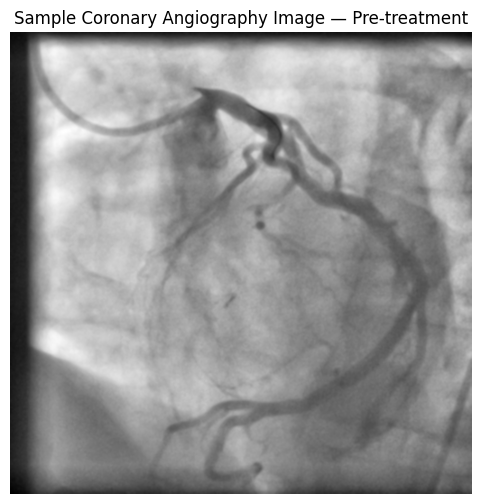

In [ ]:
import os
import cv2
import matplotlib.pyplot as plt

DATA_ROOT = "/content/drive/MyDrive/angio_ai_project/data/AngioLens_Data"
CATEGORY = "Pre-treatment"

category_path = os.path.join(DATA_ROOT, CATEGORY)

# Find all PNG images recursively
image_paths = []

for root, dirs, files in os.walk(category_path):
    for file in files:
        if file.lower().endswith(".png"):
            image_paths.append(os.path.join(root, file))

print("Number of images found:", len(image_paths))

# Select first image
sample_path = image_paths[0]

print("Selected image:")
print(sample_path)

# Read as grayscale because DCA1 model uses 1 input channel
image = cv2.imread(sample_path, cv2.IMREAD_GRAYSCALE)

print("\nImage shape:", image.shape)
print("Image dtype:", image.dtype)
print("Min pixel value:", image.min())
print("Max pixel value:", image.max())

# Display image
plt.figure(figsize=(6, 6))
plt.imshow(image, cmap="gray")
plt.title("Sample Coronary Angiography Image — Pre-treatment")
plt.axis("off")
plt.show()

Input image shape: (512, 512)
Patch size: 48
Stride: 6
Total patches: 6241

Inference completed successfully!
Probability range: 1.3711253e-05 to 0.99626637
Vessel pixels: 11408
Vessel coverage: 4.35%


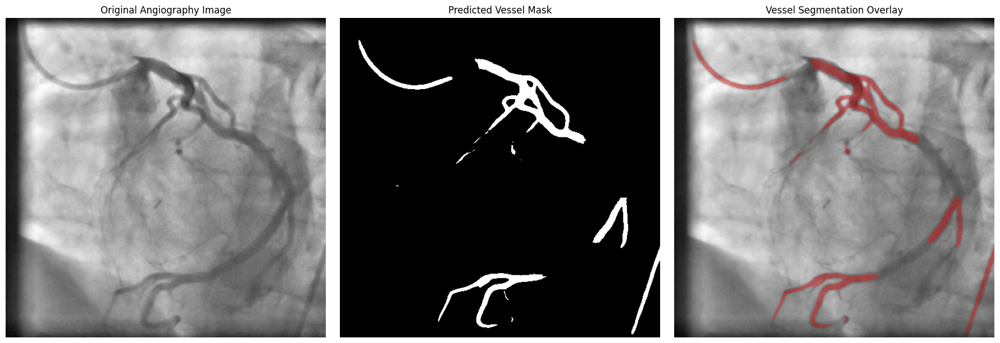

In [ ]:
import torch
import numpy as np
import cv2
import matplotlib.pyplot as plt

# ============================================================
# SETTINGS FROM THE ORIGINAL DCA1 CHECKPOINT
# ============================================================

PATCH_SIZE = 48
STRIDE = 6
THRESHOLD = 0.5
BATCH_SIZE = 256

# ============================================================
# PREPARE IMAGE
# ============================================================

# image was loaded previously as grayscale uint8
img = image.astype(np.float32) / 255.0

H, W = img.shape

print("Input image shape:", img.shape)
print("Patch size:", PATCH_SIZE)
print("Stride:", STRIDE)

# ============================================================
# GENERATE PATCH COORDINATES
# ============================================================

y_positions = list(range(0, H - PATCH_SIZE + 1, STRIDE))
x_positions = list(range(0, W - PATCH_SIZE + 1, STRIDE))

# Ensure coverage of the final image boundaries
if y_positions[-1] != H - PATCH_SIZE:
    y_positions.append(H - PATCH_SIZE)

if x_positions[-1] != W - PATCH_SIZE:
    x_positions.append(W - PATCH_SIZE)

coords = [
    (y, x)
    for y in y_positions
    for x in x_positions
]

print("Total patches:", len(coords))

# ============================================================
# OUTPUT ACCUMULATORS
# ============================================================

prob_sum = np.zeros((H, W), dtype=np.float32)
count_map = np.zeros((H, W), dtype=np.float32)

# ============================================================
# MODEL INFERENCE
# ============================================================

model.eval()

with torch.no_grad():

    for start in range(0, len(coords), BATCH_SIZE):

        batch_coords = coords[start:start + BATCH_SIZE]

        patches = []

        for y, x in batch_coords:

            patch = img[
                y:y + PATCH_SIZE,
                x:x + PATCH_SIZE
            ]

            patches.append(patch)

        batch = np.stack(patches, axis=0)

        # Shape:
        # [batch, channel, height, width]
        batch = torch.from_numpy(batch).unsqueeze(1).float().to(device)

        outputs = model(batch)

        # Handle models returning tuple/list
        if isinstance(outputs, (tuple, list)):
            outputs = outputs[-1]

        # Convert logits to probabilities only if needed
        if outputs.min() < 0 or outputs.max() > 1:
            outputs = torch.sigmoid(outputs)

        outputs = outputs.detach().cpu().numpy()

        for i, (y, x) in enumerate(batch_coords):

            pred_patch = np.squeeze(outputs[i])

            prob_sum[
                y:y + PATCH_SIZE,
                x:x + PATCH_SIZE
            ] += pred_patch

            count_map[
                y:y + PATCH_SIZE,
                x:x + PATCH_SIZE
            ] += 1.0

# ============================================================
# MERGE OVERLAPPING PATCHES
# ============================================================

probability_map = prob_sum / np.maximum(count_map, 1)

predicted_mask = (
    probability_map >= THRESHOLD
).astype(np.uint8)

print("\nInference completed successfully!")
print("Probability range:",
      probability_map.min(),
      "to",
      probability_map.max())

print("Vessel pixels:",
      int(predicted_mask.sum()))

print("Vessel coverage:",
      f"{predicted_mask.mean() * 100:.2f}%")

# ============================================================
# CREATE OVERLAY
# ============================================================

original_rgb = cv2.cvtColor(image, cv2.COLOR_GRAY2RGB)

overlay = original_rgb.copy()

# Red overlay for predicted vessels
overlay[predicted_mask == 1] = [255, 0, 0]

blended = cv2.addWeighted(
    original_rgb,
    0.65,
    overlay,
    0.35,
    0
)

# ============================================================
# DISPLAY RESULTS
# ============================================================

plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
plt.imshow(image, cmap="gray")
plt.title("Original Angiography Image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(predicted_mask, cmap="gray")
plt.title("Predicted Vessel Mask")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(blended)
plt.title("Vessel Segmentation Overlay")
plt.axis("off")

plt.tight_layout()
plt.show()

Original vessel pixels: 11408
Refined vessel pixels: 10331
Refined vessel coverage: 3.94%


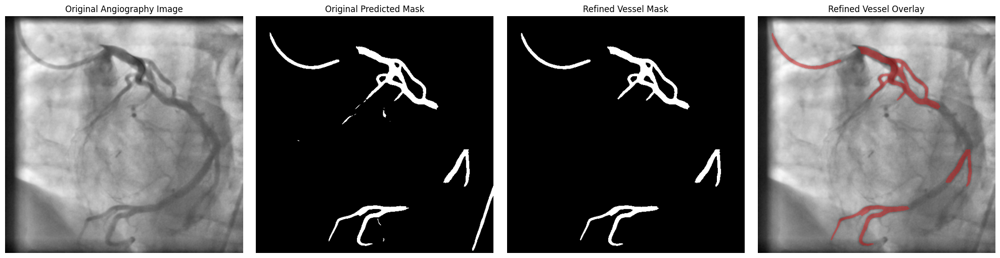

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# POST-PROCESSING SETTINGS
# ============================================================

MIN_COMPONENT_SIZE = 100
BORDER_MARGIN = 5

# Copy original predicted mask
mask = predicted_mask.copy().astype(np.uint8)

# ============================================================
# 1. MORPHOLOGICAL OPENING
# Remove isolated noise
# ============================================================

kernel = cv2.getStructuringElement(
    cv2.MORPH_ELLIPSE,
    (3, 3)
)

cleaned_mask = cv2.morphologyEx(
    mask,
    cv2.MORPH_OPEN,
    kernel
)

# ============================================================
# 2. CONNECTED COMPONENT ANALYSIS
# ============================================================

num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(
    cleaned_mask,
    connectivity=8
)

refined_mask = np.zeros_like(cleaned_mask)

for label_id in range(1, num_labels):

    area = stats[label_id, cv2.CC_STAT_AREA]

    x = stats[label_id, cv2.CC_STAT_LEFT]
    y = stats[label_id, cv2.CC_STAT_TOP]
    w = stats[label_id, cv2.CC_STAT_WIDTH]
    h = stats[label_id, cv2.CC_STAT_HEIGHT]

    # Remove very small components
    if area < MIN_COMPONENT_SIZE:
        continue

    # Detect components touching image borders
    touches_border = (
        x <= BORDER_MARGIN or
        y <= BORDER_MARGIN or
        (x + w) >= (mask.shape[1] - BORDER_MARGIN) or
        (y + h) >= (mask.shape[0] - BORDER_MARGIN)
    )

    # Remove border artifacts
    if touches_border:
        continue

    refined_mask[labels == label_id] = 1

# ============================================================
# 3. CREATE REFINED OVERLAY
# ============================================================

original_rgb = cv2.cvtColor(image, cv2.COLOR_GRAY2RGB)

overlay = original_rgb.copy()
overlay[refined_mask == 1] = [255, 0, 0]

refined_overlay = cv2.addWeighted(
    original_rgb,
    0.65,
    overlay,
    0.35,
    0
)

# ============================================================
# 4. DISPLAY COMPARISON
# ============================================================

print("Original vessel pixels:", int(predicted_mask.sum()))
print("Refined vessel pixels:", int(refined_mask.sum()))

print(
    "Refined vessel coverage:",
    f"{refined_mask.mean() * 100:.2f}%"
)

plt.figure(figsize=(20, 5))

plt.subplot(1, 4, 1)
plt.imshow(image, cmap="gray")
plt.title("Original Angiography Image")
plt.axis("off")

plt.subplot(1, 4, 2)
plt.imshow(predicted_mask, cmap="gray")
plt.title("Original Predicted Mask")
plt.axis("off")

plt.subplot(1, 4, 3)
plt.imshow(refined_mask, cmap="gray")
plt.title("Refined Vessel Mask")
plt.axis("off")

plt.subplot(1, 4, 4)
plt.imshow(refined_overlay)
plt.title("Refined Vessel Overlay")
plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
%cd /content/FR-UNet

print("=" * 70)
print("DATA_PROCESS.PY")
print("=" * 70)

with open("data_process.py", "r") as f:
    content = f.read()

print(content)

/content/FR-UNet
DATA_PROCESS.PY
import os
import argparse
import pickle
import cv2
import numpy as np
import torch.nn as nn
import torch
import torch.nn.functional as F
from PIL import Image
from ruamel.yaml import safe_load
from torchvision.transforms import Grayscale, Normalize, ToTensor
from utils.helpers import dir_exists, remove_files


def data_process(data_path, name, patch_size, stride, mode):
    save_path = os.path.join(data_path, f"{mode}_pro")
    dir_exists(save_path)
    remove_files(save_path)
    if name == "DRIVE":
        img_path = os.path.join(data_path, mode, "images")
        gt_path = os.path.join(data_path, mode, "1st_manual")
        file_list = list(sorted(os.listdir(img_path)))
    elif name == "CHASEDB1":
        file_list = list(sorted(os.listdir(data_path)))
    elif name == "STARE":
        img_path = os.path.join(data_path, "stare-images")
        gt_path = os.path.join(data_path, "labels-ah")
        file_list = list(sorted(os.listdir(img_path)))
    e

In [ ]:
%cd /content/FR-UNet

print("=" * 70)
print("TESTER.PY")
print("=" * 70)

with open("tester.py", "r") as f:
    content = f.read()

print(content)

/content/FR-UNet
TESTER.PY
import time
import cv2
import torch
import numpy as np
import torch.backends.cudnn as cudnn
import torch.nn as nn
import torchvision.transforms.functional as TF
from loguru import logger
from tqdm import tqdm
from trainer import Trainer
from utils.helpers import dir_exists, remove_files, double_threshold_iteration, double_threshold_iteration_fast
from utils.metrics import AverageMeter, get_metrics, get_metrics, count_connect_component
import ttach as tta


class Tester(Trainer):
    def __init__(self, model, loss, CFG, checkpoint, test_loader, dataset_path, show=False):
        # super(Trainer, self).__init__()
        self.loss = loss
        self.CFG = CFG
        self.test_loader = test_loader
        self.model = nn.DataParallel(model.cuda())
        self.dataset_path = dataset_path
        self.show = show
        self.model.load_state_dict(checkpoint['state_dict'])
        if self.show:
            dir_exists("save_picture")
            remove_files("sa

Input tensor shape: torch.Size([1, 1, 512, 512])
Normalized range: 0.0 to 1.0

Full-image inference completed successfully! ✅
Probability range: 4.3563605e-06 to 0.999619
Vessel pixels: 13505
Vessel coverage: 5.15%


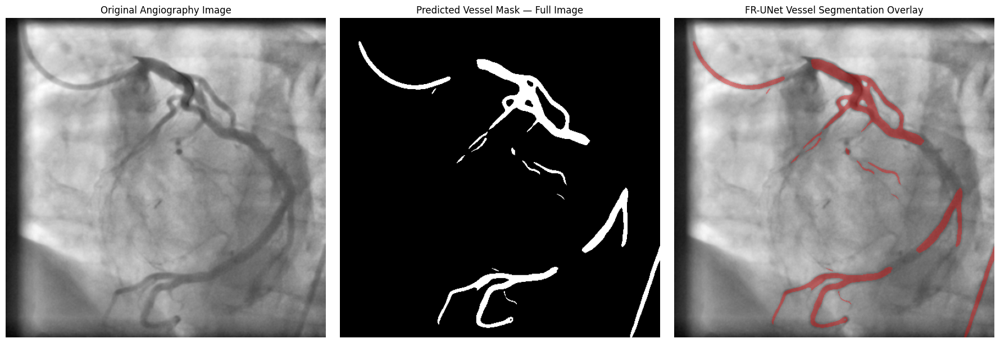

In [ ]:
import torch
import numpy as np
import cv2
import matplotlib.pyplot as plt

# ============================================================
# SETTINGS
# ============================================================

THRESHOLD = 0.5

# ============================================================
# 1. ORIGINAL FR-UNET NORMALIZATION
# ============================================================

# Convert uint8 image to tensor in [0, 1]
img_tensor = torch.from_numpy(
    image.astype(np.float32) / 255.0
).unsqueeze(0)  # [1, H, W]

# Mean and std normalization
mean = torch.mean(img_tensor)
std = torch.std(img_tensor)

normalized = (img_tensor - mean) / (std + 1e-8)

# Per-image min-max normalization
normalized = (
    normalized - torch.min(normalized)
) / (
    torch.max(normalized) - torch.min(normalized) + 1e-8
)

# Add batch dimension:
# [1, H, W] → [1, 1, H, W]
input_tensor = normalized.unsqueeze(0).to(device)

print("Input tensor shape:", input_tensor.shape)
print(
    "Normalized range:",
    float(input_tensor.min()),
    "to",
    float(input_tensor.max())
)

# ============================================================
# 2. FULL-IMAGE INFERENCE
# Same logic as tester.py
# ============================================================

model.eval()

with torch.no_grad():

    logits = model(input_tensor)

    if isinstance(logits, (tuple, list)):
        logits = logits[-1]

    probabilities = torch.sigmoid(logits)

# Convert to NumPy
probability_map_full = (
    probabilities[0, 0]
    .detach()
    .cpu()
    .numpy()
)

predicted_mask_full = (
    probability_map_full >= THRESHOLD
).astype(np.uint8)

# ============================================================
# 3. PRINT RESULTS
# ============================================================

print("\nFull-image inference completed successfully! ✅")

print(
    "Probability range:",
    probability_map_full.min(),
    "to",
    probability_map_full.max()
)

print(
    "Vessel pixels:",
    int(predicted_mask_full.sum())
)

print(
    "Vessel coverage:",
    f"{predicted_mask_full.mean() * 100:.2f}%"
)

# ============================================================
# 4. CREATE OVERLAY
# ============================================================

original_rgb = cv2.cvtColor(
    image,
    cv2.COLOR_GRAY2RGB
)

overlay = original_rgb.copy()

overlay[predicted_mask_full == 1] = [255, 0, 0]

blended_full = cv2.addWeighted(
    original_rgb,
    0.65,
    overlay,
    0.35,
    0
)

# ============================================================
# 5. DISPLAY RESULTS
# ============================================================

plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
plt.imshow(image, cmap="gray")
plt.title("Original Angiography Image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(predicted_mask_full, cmap="gray")
plt.title("Predicted Vessel Mask — Full Image")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(blended_full)
plt.title("FR-UNet Vessel Segmentation Overlay")
plt.axis("off")

plt.tight_layout()
plt.show()

Original threshold mask pixels: 13505
DTI-refined vessel pixels: 14837
DTI vessel coverage: 5.66%


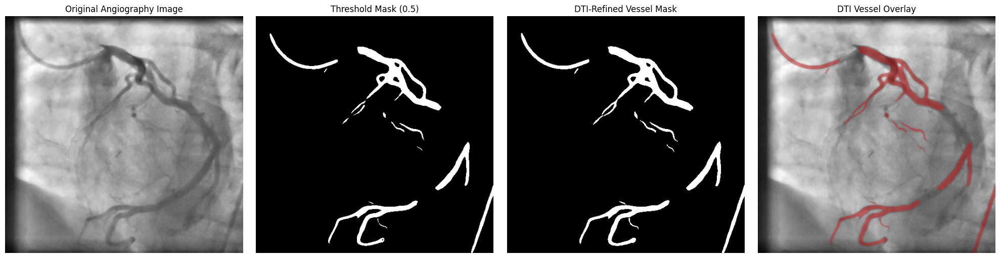

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# SAFE DTI / HYSTERESIS THRESHOLDING
# ============================================================

THRESHOLD_HIGH = 0.5
THRESHOLD_LOW = 0.4

# We already have the probability map from full-image inference
prob = probability_map_full.copy()

# Strong vessel pixels
strong = (prob >= THRESHOLD_HIGH).astype(np.uint8)

# Weak + strong candidate pixels
candidate = (prob >= THRESHOLD_LOW).astype(np.uint8)

# Keep only candidate components connected to strong pixels
num_labels, labels = cv2.connectedComponents(
    candidate,
    connectivity=8
)

dti_mask = np.zeros_like(candidate)

for label_id in range(1, num_labels):

    component = (labels == label_id)

    # Keep this component only if it contains
    # at least one strong-confidence vessel pixel
    if np.any(strong[component] == 1):
        dti_mask[component] = 1

# ============================================================
# RESULTS
# ============================================================

print(
    "Original threshold mask pixels:",
    int(predicted_mask_full.sum())
)

print(
    "DTI-refined vessel pixels:",
    int(dti_mask.sum())
)

print(
    "DTI vessel coverage:",
    f"{dti_mask.mean() * 100:.2f}%"
)

# ============================================================
# CREATE OVERLAY
# ============================================================

original_rgb = cv2.cvtColor(
    image,
    cv2.COLOR_GRAY2RGB
)

overlay_dti = original_rgb.copy()

overlay_dti[dti_mask == 1] = [255, 0, 0]

blended_dti = cv2.addWeighted(
    original_rgb,
    0.65,
    overlay_dti,
    0.35,
    0
)

# ============================================================
# DISPLAY
# ============================================================

plt.figure(figsize=(20, 5))

plt.subplot(1, 4, 1)
plt.imshow(image, cmap="gray")
plt.title("Original Angiography Image")
plt.axis("off")

plt.subplot(1, 4, 2)
plt.imshow(predicted_mask_full, cmap="gray")
plt.title("Threshold Mask (0.5)")
plt.axis("off")

plt.subplot(1, 4, 3)
plt.imshow(dti_mask, cmap="gray")
plt.title("DTI-Refined Vessel Mask")
plt.axis("off")

plt.subplot(1, 4, 4)
plt.imshow(blended_dti)
plt.title("DTI Vessel Overlay")
plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
import torch
from collections import OrderedDict
from models.fr_unet import FR_UNet

# ============================================================
# CHUAC CHECKPOINT PATH
# ============================================================

CHUAC_CHECKPOINT_PATH = (
    "/content/FR-UNet/pretrained_weights/"
    "CHUAC/checkpoint-epoch40.pth"
)

# ============================================================
# LOAD CHECKPOINT
# ============================================================

chuac_checkpoint = torch.load(
    CHUAC_CHECKPOINT_PATH,
    map_location="cpu",
    weights_only=False
)

print("CHUAC checkpoint loaded successfully! ✅")

print("\nCheckpoint keys:")
for key in chuac_checkpoint.keys():
    print("-", key)

# ============================================================
# CREATE FRESH FR-UNET MODEL
# ============================================================

model_chuac = FR_UNet()

# ============================================================
# REMOVE 'module.' PREFIX
# ============================================================

old_state_dict = chuac_checkpoint["state_dict"]

new_state_dict = OrderedDict()

for key, value in old_state_dict.items():

    new_key = (
        key.replace("module.", "", 1)
        if key.startswith("module.")
        else key
    )

    new_state_dict[new_key] = value

# ============================================================
# LOAD WEIGHTS STRICTLY
# ============================================================

try:

    model_chuac.load_state_dict(
        new_state_dict,
        strict=True
    )

    print(
        "\n✅ CHUAC model weights loaded successfully "
        "with strict=True!"
    )

except Exception as e:

    print("\n❌ CHUAC loading failed:")
    print(e)

# ============================================================
# MOVE TO GPU
# ============================================================

model_chuac = model_chuac.to(device)
model_chuac.eval()

print("\nDevice:", device)

if device.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

CHUAC checkpoint loaded successfully! ✅

Checkpoint keys:
- arch
- epoch
- state_dict
- optimizer
- monitor_best
- config

✅ CHUAC model weights loaded successfully with strict=True!

Device: cuda
GPU: Tesla T4


Input tensor shape: torch.Size([1, 1, 512, 512])
Normalized range: 0.0 to 1.0

CHUAC inference completed successfully! ✅
Probability range: 8.248745e-07 to 0.999665
Vessel pixels: 13663
Vessel coverage: 5.21%


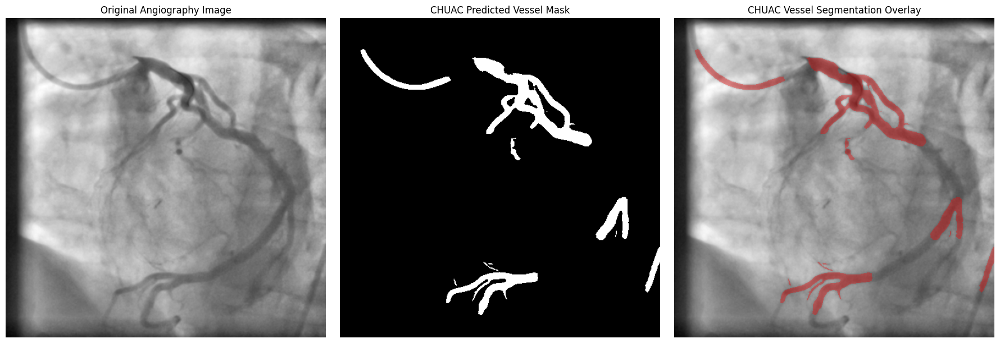

In [ ]:
import torch
import numpy as np
import cv2
import matplotlib.pyplot as plt

# ============================================================
# SETTINGS
# ============================================================

THRESHOLD = 0.5

# ============================================================
# USE THE SAME NORMALIZED INPUT
# ============================================================

print("Input tensor shape:", input_tensor.shape)
print(
    "Normalized range:",
    float(input_tensor.min()),
    "to",
    float(input_tensor.max())
)

# ============================================================
# CHUAC FULL-IMAGE INFERENCE
# ============================================================

model_chuac.eval()

with torch.no_grad():

    logits_chuac = model_chuac(input_tensor)

    if isinstance(logits_chuac, (tuple, list)):
        logits_chuac = logits_chuac[-1]

    probabilities_chuac = torch.sigmoid(logits_chuac)

# Convert to NumPy
probability_map_chuac = (
    probabilities_chuac[0, 0]
    .detach()
    .cpu()
    .numpy()
)

# Binary mask
predicted_mask_chuac = (
    probability_map_chuac >= THRESHOLD
).astype(np.uint8)

# ============================================================
# PRINT RESULTS
# ============================================================

print("\nCHUAC inference completed successfully! ✅")

print(
    "Probability range:",
    probability_map_chuac.min(),
    "to",
    probability_map_chuac.max()
)

print(
    "Vessel pixels:",
    int(predicted_mask_chuac.sum())
)

print(
    "Vessel coverage:",
    f"{predicted_mask_chuac.mean() * 100:.2f}%"
)

# ============================================================
# CREATE CHUAC OVERLAY
# ============================================================

original_rgb = cv2.cvtColor(
    image,
    cv2.COLOR_GRAY2RGB
)

overlay_chuac = original_rgb.copy()

overlay_chuac[
    predicted_mask_chuac == 1
] = [255, 0, 0]

blended_chuac = cv2.addWeighted(
    original_rgb,
    0.65,
    overlay_chuac,
    0.35,
    0
)

# ============================================================
# DISPLAY RESULTS
# ============================================================

plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
plt.imshow(image, cmap="gray")
plt.title("Original Angiography Image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(predicted_mask_chuac, cmap="gray")
plt.title("CHUAC Predicted Vessel Mask")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(blended_chuac)
plt.title("CHUAC Vessel Segmentation Overlay")
plt.axis("off")

plt.tight_layout()
plt.show()

Normal: 1089 images
Selected: /content/drive/MyDrive/angio_ai_project/data/AngioLens_Data/Normal/CD8/ST2/Patient_ca-normal_ST2_S5/Final_Core_Frames/1_core_frame_05.png
----------------------------------------------------------------------
Post-treatment: 3598 images
Selected: /content/drive/MyDrive/angio_ai_project/data/AngioLens_Data/Post-treatment/4/ST38/S8/frame_07.png
----------------------------------------------------------------------
Pre-treatment: 3416 images
Selected: /content/drive/MyDrive/angio_ai_project/data/AngioLens_Data/Pre-treatment/4/ST37/S4/frame_04.png
----------------------------------------------------------------------
Unique Stenosis Views: 1614 images
Selected: /content/drive/MyDrive/angio_ai_project/data/AngioLens_Data/Unique Stenosis Views/4/ST38/S3/frame_02.png
----------------------------------------------------------------------


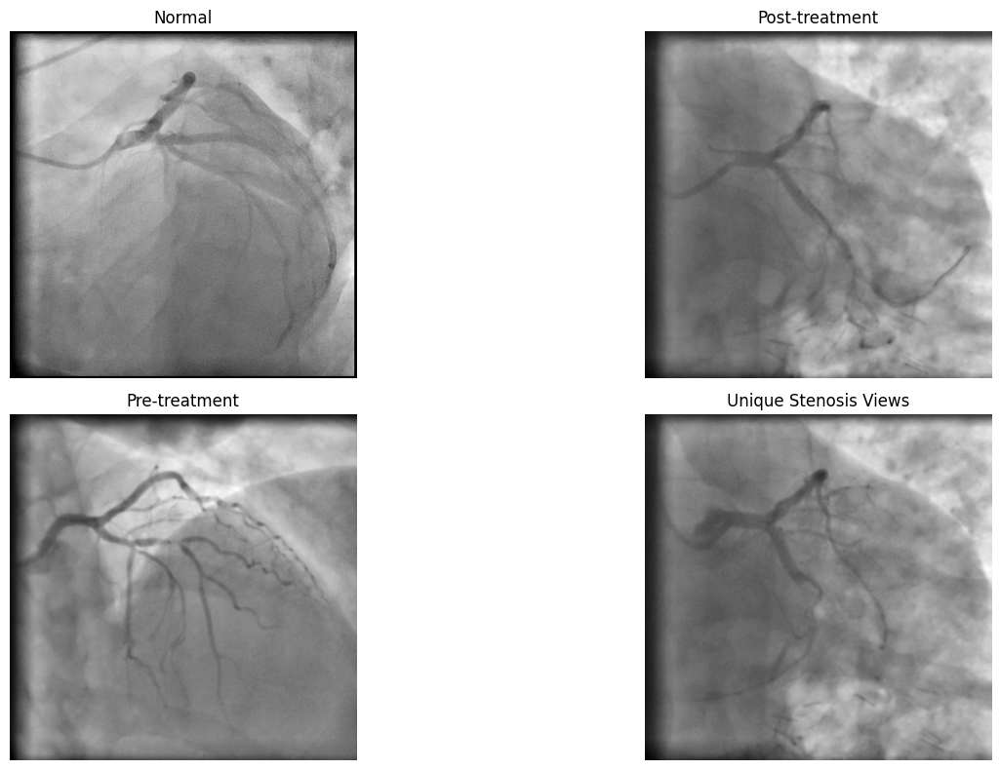

In [ ]:
import os
import cv2
import matplotlib.pyplot as plt

DATA_ROOT = "/content/drive/MyDrive/angio_ai_project/data/AngioLens_Data"

categories = [
    "Normal",
    "Post-treatment",
    "Pre-treatment",
    "Unique Stenosis Views"
]

sample_images = {}

for category in categories:

    category_path = os.path.join(DATA_ROOT, category)

    image_paths = []

    for root, dirs, files in os.walk(category_path):
        for file in files:
            if file.lower().endswith(".png"):
                image_paths.append(os.path.join(root, file))

    image_paths = sorted(image_paths)

    if len(image_paths) > 0:
        # Choose a middle image instead of always the first one
        selected_path = image_paths[len(image_paths) // 2]

        selected_image = cv2.imread(
            selected_path,
            cv2.IMREAD_GRAYSCALE
        )

        sample_images[category] = {
            "path": selected_path,
            "image": selected_image
        }

        print(f"{category}: {len(image_paths)} images")
        print(f"Selected: {selected_path}")
        print("-" * 70)

# Display selected images
plt.figure(figsize=(16, 8))

for i, category in enumerate(categories):

    plt.subplot(2, 2, i + 1)

    plt.imshow(
        sample_images[category]["image"],
        cmap="gray"
    )

    plt.title(category)
    plt.axis("off")

plt.tight_layout()
plt.show()

Processing: Normal
DCA1  coverage: 3.20%
CHUAC coverage: 0.29%
Processing: Post-treatment
DCA1  coverage: 1.79%
CHUAC coverage: 1.36%
Processing: Pre-treatment
DCA1  coverage: 4.53%
CHUAC coverage: 4.70%
Processing: Unique Stenosis Views
DCA1  coverage: 2.12%
CHUAC coverage: 1.29%


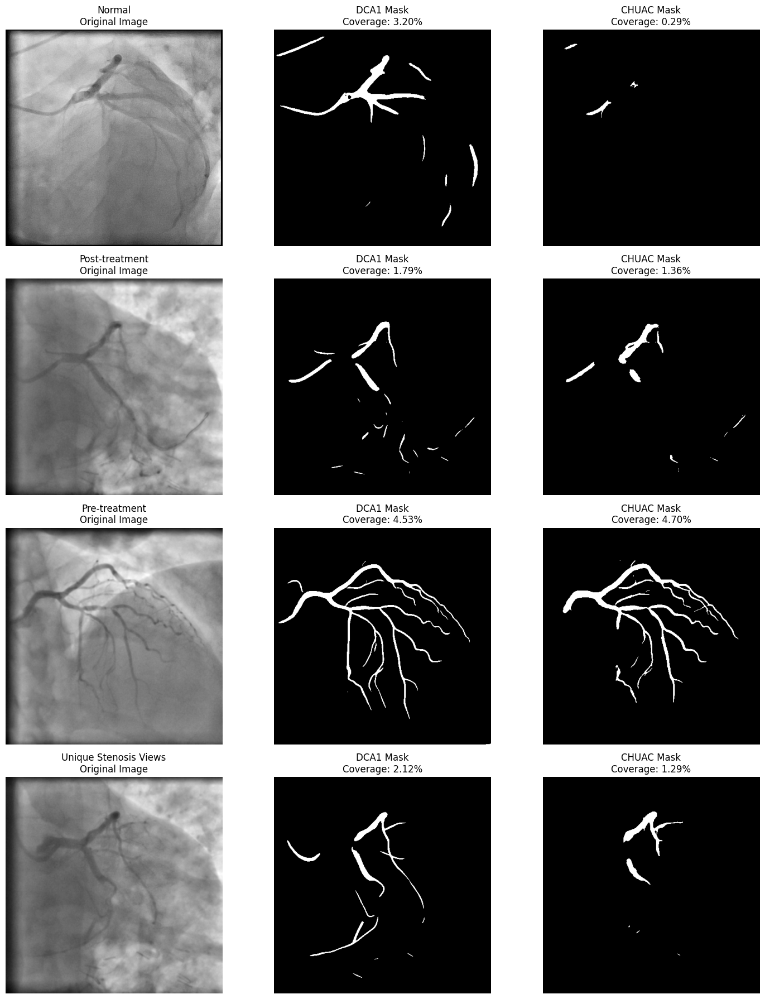

In [ ]:
import torch
import numpy as np
import cv2
import matplotlib.pyplot as plt

THRESHOLD = 0.5


# ============================================================
# NORMALIZATION FUNCTION
# Same preprocessing logic used by FR-UNet
# ============================================================

def prepare_image_for_model(img):

    img_tensor = torch.from_numpy(
        img.astype(np.float32) / 255.0
    ).unsqueeze(0)

    mean = torch.mean(img_tensor)
    std = torch.std(img_tensor)

    normalized = (img_tensor - mean) / (std + 1e-8)

    normalized = (
        normalized - torch.min(normalized)
    ) / (
        torch.max(normalized) - torch.min(normalized) + 1e-8
    )

    # [1, H, W] -> [1, 1, H, W]
    return normalized.unsqueeze(0).to(device)


# ============================================================
# INFERENCE FUNCTION
# ============================================================

def run_inference(model, img, threshold=0.5):

    input_tensor_local = prepare_image_for_model(img)

    model.eval()

    with torch.no_grad():

        logits_local = model(input_tensor_local)

        if isinstance(logits_local, (tuple, list)):
            logits_local = logits_local[-1]

        probabilities_local = torch.sigmoid(logits_local)

    probability_map = (
        probabilities_local[0, 0]
        .detach()
        .cpu()
        .numpy()
    )

    mask = (
        probability_map >= threshold
    ).astype(np.uint8)

    return probability_map, mask


# ============================================================
# RUN BOTH MODELS ON ALL FOUR CATEGORIES
# ============================================================

comparison_results = {}

for category in categories:

    img = sample_images[category]["image"]

    print("=" * 70)
    print("Processing:", category)

    # DCA1
    prob_dca1, mask_dca1 = run_inference(
        model,
        img,
        THRESHOLD
    )

    # CHUAC
    prob_chuac, mask_chuac = run_inference(
        model_chuac,
        img,
        THRESHOLD
    )

    comparison_results[category] = {
        "image": img,
        "dca1_probability": prob_dca1,
        "dca1_mask": mask_dca1,
        "chuac_probability": prob_chuac,
        "chuac_mask": mask_chuac
    }

    print(
        f"DCA1  coverage: "
        f"{mask_dca1.mean() * 100:.2f}%"
    )

    print(
        f"CHUAC coverage: "
        f"{mask_chuac.mean() * 100:.2f}%"
    )


# ============================================================
# DISPLAY COMPARISON
# Rows = categories
# Columns = Original | DCA1 | CHUAC
# ============================================================

fig, axes = plt.subplots(
    len(categories),
    3,
    figsize=(15, 18)
)

for row, category in enumerate(categories):

    result = comparison_results[category]

    axes[row, 0].imshow(
        result["image"],
        cmap="gray"
    )
    axes[row, 0].set_title(
        f"{category}\nOriginal Image"
    )

    axes[row, 1].imshow(
        result["dca1_mask"],
        cmap="gray"
    )
    axes[row, 1].set_title(
        f"DCA1 Mask\n"
        f"Coverage: "
        f"{result['dca1_mask'].mean() * 100:.2f}%"
    )

    axes[row, 2].imshow(
        result["chuac_mask"],
        cmap="gray"
    )
    axes[row, 2].set_title(
        f"CHUAC Mask\n"
        f"Coverage: "
        f"{result['chuac_mask'].mean() * 100:.2f}%"
    )

    for col in range(3):
        axes[row, col].axis("off")

plt.tight_layout()
plt.show()

Processing category: Normal
Total images available: 1089
Sample 1: Coverage = 2.84%
Sample 2: Coverage = 2.67%
Sample 3: Coverage = 3.20%
Sample 4: Coverage = 3.91%
Sample 5: Coverage = 2.46%
Processing category: Post-treatment
Total images available: 3598
Sample 1: Coverage = 4.16%
Sample 2: Coverage = 8.36%
Sample 3: Coverage = 1.23%
Sample 4: Coverage = 0.65%
Sample 5: Coverage = 3.85%
Processing category: Pre-treatment
Total images available: 3416
Sample 1: Coverage = 3.08%
Sample 2: Coverage = 4.47%
Sample 3: Coverage = 4.16%
Sample 4: Coverage = 6.08%
Sample 5: Coverage = 2.20%
Processing category: Unique Stenosis Views
Total images available: 1614
Sample 1: Coverage = 3.08%
Sample 2: Coverage = 3.07%
Sample 3: Coverage = 1.66%
Sample 4: Coverage = 2.58%
Sample 5: Coverage = 5.31%


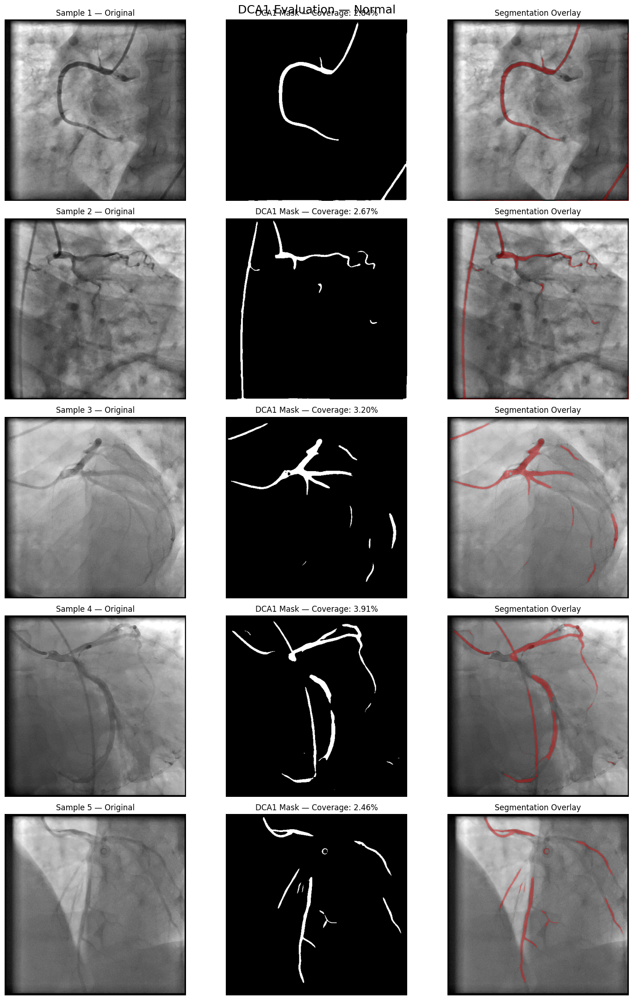

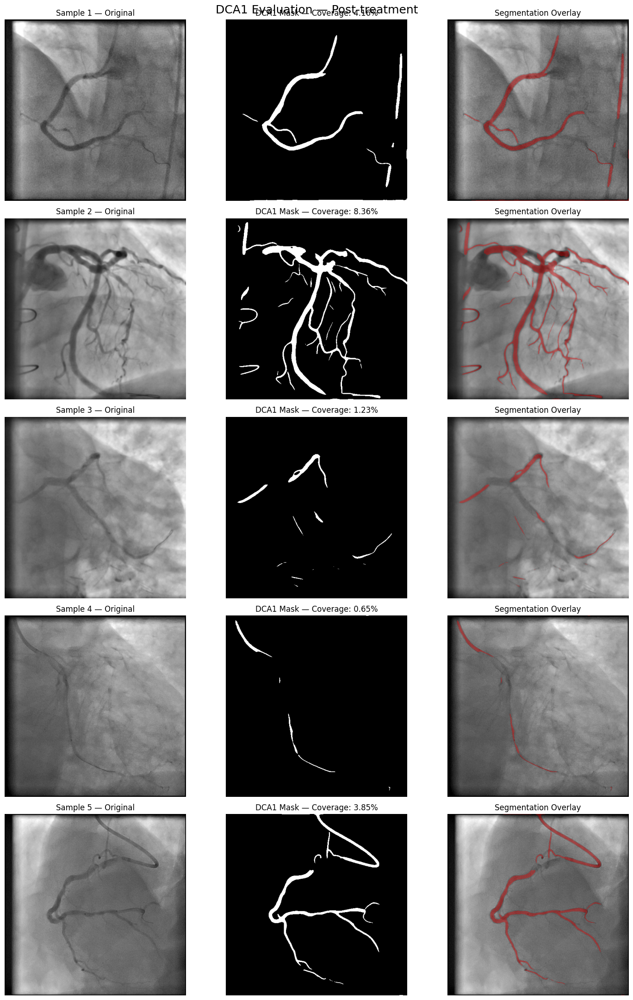

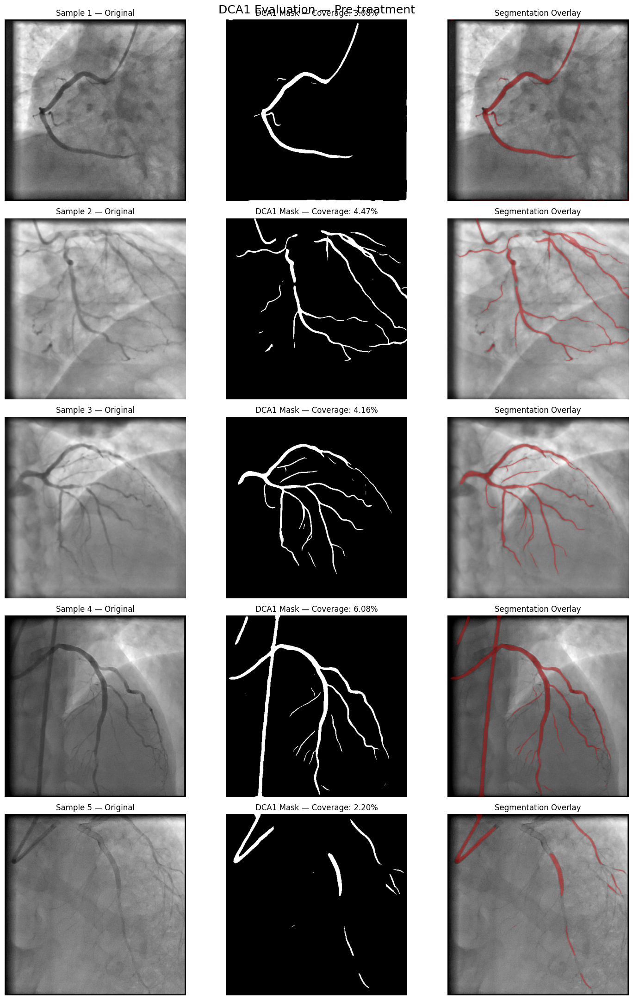

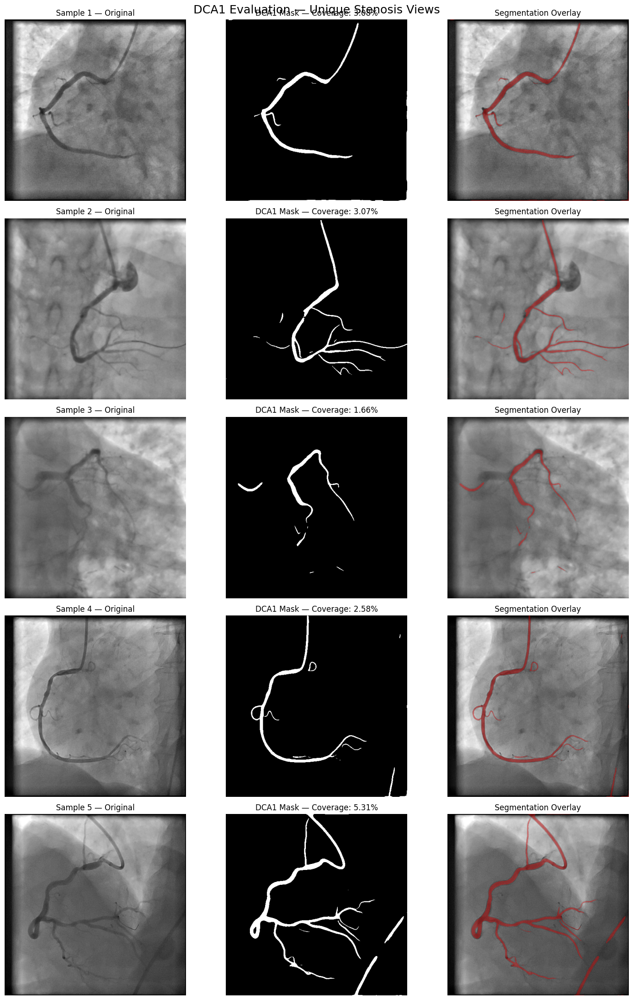

In [ ]:
import os
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# SETTINGS
# ============================================================

DATA_ROOT = "/content/drive/MyDrive/angio_ai_project/data/AngioLens_Data"

categories = [
    "Normal",
    "Post-treatment",
    "Pre-treatment",
    "Unique Stenosis Views"
]

NUM_SAMPLES = 5
THRESHOLD = 0.5


# ============================================================
# PREPROCESSING FUNCTION
# Same normalization used by FR-UNet
# ============================================================

def prepare_image_for_model(img):

    img_tensor = torch.from_numpy(
        img.astype(np.float32) / 255.0
    ).unsqueeze(0)

    mean = torch.mean(img_tensor)
    std = torch.std(img_tensor)

    normalized = (
        img_tensor - mean
    ) / (
        std + 1e-8
    )

    normalized = (
        normalized - torch.min(normalized)
    ) / (
        torch.max(normalized) - torch.min(normalized) + 1e-8
    )

    return normalized.unsqueeze(0).to(device)


# ============================================================
# DCA1 INFERENCE FUNCTION
# ============================================================

def run_dca1_inference(img):

    input_tensor_local = prepare_image_for_model(img)

    model.eval()

    with torch.no_grad():

        logits_local = model(input_tensor_local)

        if isinstance(logits_local, (tuple, list)):
            logits_local = logits_local[-1]

        probabilities = torch.sigmoid(logits_local)

    probability_map = (
        probabilities[0, 0]
        .detach()
        .cpu()
        .numpy()
    )

    mask = (
        probability_map >= THRESHOLD
    ).astype(np.uint8)

    return probability_map, mask


# ============================================================
# SELECT 5 DISTRIBUTED IMAGES FROM EACH CATEGORY
# ============================================================

results_20 = {}

for category in categories:

    category_path = os.path.join(
        DATA_ROOT,
        category
    )

    image_paths = []

    for root, dirs, files in os.walk(category_path):

        for file in files:

            if file.lower().endswith(".png"):

                image_paths.append(
                    os.path.join(root, file)
                )

    image_paths = sorted(image_paths)

    # Select 5 distributed samples across the whole category
    indices = np.linspace(
        0,
        len(image_paths) - 1,
        NUM_SAMPLES,
        dtype=int
    )

    selected_paths = [
        image_paths[i]
        for i in indices
    ]

    results_20[category] = []

    print("=" * 70)
    print(f"Processing category: {category}")
    print(f"Total images available: {len(image_paths)}")

    for sample_number, path in enumerate(selected_paths, start=1):

        img = cv2.imread(
            path,
            cv2.IMREAD_GRAYSCALE
        )

        probability_map, mask = run_dca1_inference(img)

        # Create overlay
        original_rgb = cv2.cvtColor(
            img,
            cv2.COLOR_GRAY2RGB
        )

        overlay = original_rgb.copy()

        overlay[mask == 1] = [255, 0, 0]

        blended = cv2.addWeighted(
            original_rgb,
            0.65,
            overlay,
            0.35,
            0
        )

        coverage = mask.mean() * 100

        results_20[category].append({
            "image": img,
            "mask": mask,
            "overlay": blended,
            "coverage": coverage,
            "path": path
        })

        print(
            f"Sample {sample_number}: "
            f"Coverage = {coverage:.2f}%"
        )


# ============================================================
# DISPLAY RESULTS
# One figure for each category
# ============================================================

for category in categories:

    category_results = results_20[category]

    fig, axes = plt.subplots(
        NUM_SAMPLES,
        3,
        figsize=(15, 22)
    )

    fig.suptitle(
        f"DCA1 Evaluation — {category}",
        fontsize=18
    )

    for row, result in enumerate(category_results):

        # Original
        axes[row, 0].imshow(
            result["image"],
            cmap="gray"
        )

        axes[row, 0].set_title(
            f"Sample {row + 1} — Original"
        )

        # Mask
        axes[row, 1].imshow(
            result["mask"],
            cmap="gray"
        )

        axes[row, 1].set_title(
            f"DCA1 Mask — Coverage: "
            f"{result['coverage']:.2f}%"
        )

        # Overlay
        axes[row, 2].imshow(
            result["overlay"]
        )

        axes[row, 2].set_title(
            "Segmentation Overlay"
        )

        for col in range(3):
            axes[row, col].axis("off")

    plt.tight_layout()
    plt.show()

In [ ]:
import os

FINETUNE_ROOT = "/content/drive/MyDrive/angio_ai_project/AngioLens_FineTuning_200"

categories = [
    "Normal",
    "Post-treatment",
    "Pre-treatment",
    "Unique Stenosis Views"
]

for main_folder in ["images", "pseudo_masks"]:
    for category in categories:
        folder_path = os.path.join(
            FINETUNE_ROOT,
            main_folder,
            category
        )
        os.makedirs(folder_path, exist_ok=True)

print("✅ Fine-tuning folder structure created successfully!")

for root, dirs, files in os.walk(FINETUNE_ROOT):
    level = root.replace(FINETUNE_ROOT, "").count(os.sep)
    indent = "    " * level
    print(f"{indent}{os.path.basename(root)}/")

✅ Fine-tuning folder structure created successfully!
AngioLens_FineTuning_200/
    images/
        Normal/
        Post-treatment/
        Pre-treatment/
        Unique Stenosis Views/
    pseudo_masks/
        Normal/
        Post-treatment/
        Pre-treatment/
        Unique Stenosis Views/
    Selected_100/
        images/
            Normal/
            Post-treatment/
            Pre-treatment/
            Unique Stenosis Views/
        pseudo_masks/
            Normal/
            Post-treatment/
            Pre-treatment/
            Unique Stenosis Views/
    Consensus_Selected_100/
        images/
            Normal/
            Post-treatment/
            Pre-treatment/
            Unique Stenosis Views/
        final_consensus_masks/
            Normal/
            Post-treatment/
            Pre-treatment/
            Unique Stenosis Views/
        clean_consensus_masks/
            Normal/
            Post-treatment/
            Pre-treatment/
            Unique Stenosi

In [ ]:
import os
import shutil
import numpy as np
from collections import defaultdict

# ============================================================
# PATHS
# ============================================================

DATA_ROOT = "/content/drive/MyDrive/angio_ai_project/data/AngioLens_Data"

FINETUNE_ROOT = "/content/drive/MyDrive/angio_ai_project/AngioLens_FineTuning_200"

IMAGES_OUTPUT = os.path.join(FINETUNE_ROOT, "images")

# ============================================================
# SETTINGS
# ============================================================

categories = [
    "Normal",
    "Post-treatment",
    "Pre-treatment",
    "Unique Stenosis Views"
]

NUM_SAMPLES_PER_CATEGORY = 50

# ============================================================
# SELECT DIVERSE IMAGES
# ============================================================

selected_summary = {}

for category in categories:

    print("=" * 70)
    print(f"Processing category: {category}")

    category_path = os.path.join(DATA_ROOT, category)
    output_path = os.path.join(IMAGES_OUTPUT, category)

    os.makedirs(output_path, exist_ok=True)

    # --------------------------------------------------------
    # Group images by their immediate parent folder
    # --------------------------------------------------------

    groups = defaultdict(list)

    for root, dirs, files in os.walk(category_path):

        for file in files:

            if file.lower().endswith(".png"):

                full_path = os.path.join(root, file)

                relative_parent = os.path.relpath(
                    root,
                    category_path
                )

                groups[relative_parent].append(full_path)

    print(f"Number of source groups found: {len(groups)}")

    # Sort images inside each group
    for group in groups:
        groups[group] = sorted(groups[group])

    # --------------------------------------------------------
    # Round-robin selection across different groups
    # --------------------------------------------------------

    selected = []

    group_names = sorted(groups.keys())

    round_index = 0

    while len(selected) < NUM_SAMPLES_PER_CATEGORY:

        added_this_round = False

        for group_name in group_names:

            group_images = groups[group_name]

            if round_index < len(group_images):

                selected.append(group_images[round_index])

                added_this_round = True

                if len(selected) == NUM_SAMPLES_PER_CATEGORY:
                    break

        if not added_this_round:
            break

        round_index += 1

    # --------------------------------------------------------
    # Copy selected images with unique filenames
    # --------------------------------------------------------

    copied_files = []

    for index, source_path in enumerate(selected, start=1):

        original_name = os.path.basename(source_path)

        new_filename = (
            f"{index:03d}_"
            f"{original_name}"
        )

        destination_path = os.path.join(
            output_path,
            new_filename
        )

        shutil.copy2(
            source_path,
            destination_path
        )

        copied_files.append(destination_path)

    selected_summary[category] = copied_files

    print(f"Selected and copied: {len(copied_files)} images")

# ============================================================
# FINAL SUMMARY
# ============================================================

print("\n" + "=" * 70)
print("FINAL SUMMARY")
print("=" * 70)

total_selected = 0

for category in categories:

    count = len(selected_summary[category])

    total_selected += count

    print(f"{category}: {count} images")

print("-" * 70)
print(f"Total selected images: {total_selected}")

Processing category: Normal
Number of source groups found: 118
Selected and copied: 50 images
Processing category: Post-treatment
Number of source groups found: 430
Selected and copied: 50 images
Processing category: Pre-treatment
Number of source groups found: 402
Selected and copied: 50 images
Processing category: Unique Stenosis Views
Number of source groups found: 191
Selected and copied: 50 images

FINAL SUMMARY
Normal: 50 images
Post-treatment: 50 images
Pre-treatment: 50 images
Unique Stenosis Views: 50 images
----------------------------------------------------------------------
Total selected images: 200


In [ ]:
import os
import cv2
import torch
import numpy as np
from tqdm.auto import tqdm

# ============================================================
# PATHS
# ============================================================

FINETUNE_ROOT = (
    "/content/drive/MyDrive/angio_ai_project/"
    "AngioLens_FineTuning_200"
)

IMAGES_ROOT = os.path.join(
    FINETUNE_ROOT,
    "images"
)

MASKS_ROOT = os.path.join(
    FINETUNE_ROOT,
    "pseudo_masks"
)

# ============================================================
# SETTINGS
# ============================================================

categories = [
    "Normal",
    "Post-treatment",
    "Pre-treatment",
    "Unique Stenosis Views"
]

THRESHOLD = 0.5


# ============================================================
# PREPROCESSING
# Same normalization used by FR-UNet
# ============================================================

def prepare_image_for_dca1(img):

    img_tensor = torch.from_numpy(
        img.astype(np.float32) / 255.0
    ).unsqueeze(0)

    mean = torch.mean(img_tensor)
    std = torch.std(img_tensor)

    normalized = (
        img_tensor - mean
    ) / (
        std + 1e-8
    )

    normalized = (
        normalized - torch.min(normalized)
    ) / (
        torch.max(normalized) - torch.min(normalized) + 1e-8
    )

    # [1, H, W] -> [1, 1, H, W]
    return normalized.unsqueeze(0).to(device)


# ============================================================
# DCA1 INFERENCE
# ============================================================

def generate_dca1_mask(img, threshold=0.5):

    input_tensor_local = prepare_image_for_dca1(img)

    model.eval()

    with torch.no_grad():

        logits_local = model(input_tensor_local)

        if isinstance(logits_local, (tuple, list)):
            logits_local = logits_local[-1]

        probabilities = torch.sigmoid(logits_local)

    probability_map = (
        probabilities[0, 0]
        .detach()
        .cpu()
        .numpy()
    )

    binary_mask = (
        probability_map >= threshold
    ).astype(np.uint8)

    return binary_mask, probability_map


# ============================================================
# GENERATE PSEUDO-MASKS
# ============================================================

generation_summary = {}

for category in categories:

    print("\n" + "=" * 70)
    print(f"Generating pseudo-masks: {category}")
    print("=" * 70)

    image_folder = os.path.join(
        IMAGES_ROOT,
        category
    )

    mask_folder = os.path.join(
        MASKS_ROOT,
        category
    )

    os.makedirs(
        mask_folder,
        exist_ok=True
    )

    image_files = sorted([
        file
        for file in os.listdir(image_folder)
        if file.lower().endswith(
            (".png", ".jpg", ".jpeg")
        )
    ])

    generated_count = 0
    failed_count = 0
    coverages = []

    for filename in tqdm(
        image_files,
        desc=category
    ):

        image_path = os.path.join(
            image_folder,
            filename
        )

        img = cv2.imread(
            image_path,
            cv2.IMREAD_GRAYSCALE
        )

        if img is None:

            print(
                f"⚠️ Could not read: {filename}"
            )

            failed_count += 1
            continue

        try:

            binary_mask, probability_map = (
                generate_dca1_mask(
                    img,
                    threshold=THRESHOLD
                )
            )

            # Save mask as 0 or 255
            mask_to_save = (
                binary_mask * 255
            ).astype(np.uint8)

            # Keep exactly the same filename
            mask_path = os.path.join(
                mask_folder,
                filename
            )

            success = cv2.imwrite(
                mask_path,
                mask_to_save
            )

            if success:

                generated_count += 1

                coverage = (
                    binary_mask.mean() * 100
                )

                coverages.append(coverage)

            else:

                failed_count += 1

        except Exception as e:

            print(
                f"\n❌ Error with {filename}: {e}"
            )

            failed_count += 1

    # Save category summary
    generation_summary[category] = {
        "generated": generated_count,
        "failed": failed_count,
        "mean_coverage": (
            float(np.mean(coverages))
            if coverages else 0.0
        ),
        "min_coverage": (
            float(np.min(coverages))
            if coverages else 0.0
        ),
        "max_coverage": (
            float(np.max(coverages))
            if coverages else 0.0
        )
    }


# ============================================================
# FINAL SUMMARY
# ============================================================

print("\n" + "=" * 70)
print("PSEUDO-MASK GENERATION SUMMARY")
print("=" * 70)

total_generated = 0
total_failed = 0

for category in categories:

    stats = generation_summary[category]

    total_generated += stats["generated"]
    total_failed += stats["failed"]

    print(f"\n{category}")
    print(
        f"  Generated     : "
        f"{stats['generated']}"
    )
    print(
        f"  Failed        : "
        f"{stats['failed']}"
    )
    print(
        f"  Mean coverage : "
        f"{stats['mean_coverage']:.2f}%"
    )
    print(
        f"  Min coverage  : "
        f"{stats['min_coverage']:.2f}%"
    )
    print(
        f"  Max coverage  : "
        f"{stats['max_coverage']:.2f}%"
    )

print("\n" + "-" * 70)
print(
    f"Total generated pseudo-masks: "
    f"{total_generated}"
)
print(
    f"Total failed: "
    f"{total_failed}"
)


Generating pseudo-masks: Normal


Normal:   0%|          | 0/50 [00:00<?, ?it/s]


Generating pseudo-masks: Post-treatment


Post-treatment:   0%|          | 0/50 [00:00<?, ?it/s]


Generating pseudo-masks: Pre-treatment


Pre-treatment:   0%|          | 0/50 [00:00<?, ?it/s]


Generating pseudo-masks: Unique Stenosis Views


Unique Stenosis Views:   0%|          | 0/50 [00:00<?, ?it/s]


PSEUDO-MASK GENERATION SUMMARY

Normal
  Generated     : 50
  Failed        : 0
  Mean coverage : 3.17%
  Min coverage  : 0.73%
  Max coverage  : 5.58%

Post-treatment
  Generated     : 50
  Failed        : 0
  Mean coverage : 2.85%
  Min coverage  : 0.69%
  Max coverage  : 5.04%

Pre-treatment
  Generated     : 50
  Failed        : 0
  Mean coverage : 3.31%
  Min coverage  : 0.73%
  Max coverage  : 6.02%

Unique Stenosis Views
  Generated     : 50
  Failed        : 0
  Mean coverage : 3.37%
  Min coverage  : 0.73%
  Max coverage  : 6.02%

----------------------------------------------------------------------
Total generated pseudo-masks: 200
Total failed: 0


In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# PATHS
# ============================================================

FINETUNE_ROOT = (
    "/content/drive/MyDrive/angio_ai_project/"
    "AngioLens_FineTuning_200"
)

IMAGES_ROOT = os.path.join(FINETUNE_ROOT, "images")
MASKS_ROOT = os.path.join(FINETUNE_ROOT, "pseudo_masks")

categories = [
    "Normal",
    "Post-treatment",
    "Pre-treatment",
    "Unique Stenosis Views"
]

# ============================================================
# ANALYZE AND DISPLAY REPRESENTATIVE MASKS
# ============================================================

representative_results = {}

for category in categories:

    image_folder = os.path.join(IMAGES_ROOT, category)
    mask_folder = os.path.join(MASKS_ROOT, category)

    filenames = sorted([
        f for f in os.listdir(image_folder)
        if f.lower().endswith((".png", ".jpg", ".jpeg"))
    ])

    samples = []

    for filename in filenames:

        image_path = os.path.join(image_folder, filename)
        mask_path = os.path.join(mask_folder, filename)

        image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

        if image is None or mask is None:
            continue

        binary_mask = (mask > 127).astype(np.uint8)
        coverage = binary_mask.mean() * 100

        samples.append({
            "filename": filename,
            "image": image,
            "mask": binary_mask,
            "coverage": coverage
        })

    # Sort from lowest to highest coverage
    samples = sorted(samples, key=lambda x: x["coverage"])

    # Select:
    # Minimum, 25th percentile, Median, 75th percentile, Maximum
    indices = np.linspace(
        0,
        len(samples) - 1,
        5,
        dtype=int
    )

    selected = [samples[i] for i in indices]

    representative_results[category] = selected

    print("\n" + "=" * 70)
    print(category)
    print("=" * 70)

    for i, sample in enumerate(selected, start=1):
        print(
            f"Sample {i}: "
            f"{sample['filename']} | "
            f"Coverage = {sample['coverage']:.2f}%"
        )

    # ========================================================
    # DISPLAY: Original | Mask | Overlay
    # ========================================================

    fig, axes = plt.subplots(
        5,
        3,
        figsize=(15, 22)
    )

    fig.suptitle(
        f"DCA1 Pseudo-Mask Quality Review — {category}",
        fontsize=18,
        y=1.01
    )

    for row, sample in enumerate(selected):

        image = sample["image"]
        mask = sample["mask"]
        coverage = sample["coverage"]

        # Create overlay
        original_rgb = cv2.cvtColor(
            image,
            cv2.COLOR_GRAY2RGB
        )

        overlay = original_rgb.copy()
        overlay[mask == 1] = [255, 0, 0]

        blended = cv2.addWeighted(
            original_rgb,
            0.65,
            overlay,
            0.35,
            0
        )

        # Original
        axes[row, 0].imshow(image, cmap="gray")
        axes[row, 0].set_title(
            f"Original — Sample {row + 1}"
        )

        # Mask
        axes[row, 1].imshow(mask, cmap="gray")
        axes[row, 1].set_title(
            f"Pseudo-Mask — {coverage:.2f}%"
        )

        # Overlay
        axes[row, 2].imshow(blended)
        axes[row, 2].set_title(
            "Segmentation Overlay"
        )

        for col in range(3):
            axes[row, col].axis("off")

    plt.tight_layout()
    plt.show()

In [ ]:
import os
import cv2
import shutil
import numpy as np

# ============================================================
# PATHS
# ============================================================

FINETUNE_ROOT = (
    "/content/drive/MyDrive/angio_ai_project/"
    "AngioLens_FineTuning_200"
)

IMAGES_ROOT = os.path.join(
    FINETUNE_ROOT,
    "images"
)

MASKS_ROOT = os.path.join(
    FINETUNE_ROOT,
    "pseudo_masks"
)

SELECTED_ROOT = os.path.join(
    FINETUNE_ROOT,
    "Selected_100"
)

categories = [
    "Normal",
    "Post-treatment",
    "Pre-treatment",
    "Unique Stenosis Views"
]

NUM_PER_CATEGORY = 25


# ============================================================
# CREATE OUTPUT FOLDERS
# ============================================================

for category in categories:

    os.makedirs(
        os.path.join(
            SELECTED_ROOT,
            "images",
            category
        ),
        exist_ok=True
    )

    os.makedirs(
        os.path.join(
            SELECTED_ROOT,
            "pseudo_masks",
            category
        ),
        exist_ok=True
    )


# ============================================================
# SELECT 25 REPRESENTATIVE IMAGES PER CATEGORY
# Distributed across coverage levels
# ============================================================

selection_summary = {}

for category in categories:

    image_folder = os.path.join(
        IMAGES_ROOT,
        category
    )

    mask_folder = os.path.join(
        MASKS_ROOT,
        category
    )

    samples = []

    filenames = sorted([
        f for f in os.listdir(image_folder)
        if f.lower().endswith(
            (".png", ".jpg", ".jpeg")
        )
    ])

    for filename in filenames:

        image_path = os.path.join(
            image_folder,
            filename
        )

        mask_path = os.path.join(
            mask_folder,
            filename
        )

        mask = cv2.imread(
            mask_path,
            cv2.IMREAD_GRAYSCALE
        )

        if mask is None:
            continue

        binary_mask = (
            mask > 127
        ).astype(np.uint8)

        coverage = (
            binary_mask.mean() * 100
        )

        samples.append({
            "filename": filename,
            "image_path": image_path,
            "mask_path": mask_path,
            "coverage": coverage
        })

    # Sort from lowest to highest coverage
    samples = sorted(
        samples,
        key=lambda x: x["coverage"]
    )

    # Select 25 distributed samples across full coverage range
    indices = np.linspace(
        0,
        len(samples) - 1,
        NUM_PER_CATEGORY,
        dtype=int
    )

    selected = [
        samples[i]
        for i in indices
    ]

    selection_summary[category] = selected

    # Copy selected images and masks
    for sample in selected:

        filename = sample["filename"]

        image_destination = os.path.join(
            SELECTED_ROOT,
            "images",
            category,
            filename
        )

        mask_destination = os.path.join(
            SELECTED_ROOT,
            "pseudo_masks",
            category,
            filename
        )

        shutil.copy2(
            sample["image_path"],
            image_destination
        )

        shutil.copy2(
            sample["mask_path"],
            mask_destination
        )

    print("\n" + "=" * 70)
    print(category)
    print("=" * 70)

    print(
        f"Selected: {len(selected)} images"
    )

    print(
        f"Coverage range: "
        f"{selected[0]['coverage']:.2f}% "
        f"to "
        f"{selected[-1]['coverage']:.2f}%"
    )


# ============================================================
# FINAL SUMMARY
# ============================================================

print("\n" + "=" * 70)
print("FINAL SELECTION SUMMARY")
print("=" * 70)

total = 0

for category in categories:

    count = len(
        selection_summary[category]
    )

    total += count

    print(
        f"{category}: {count} images"
    )

print("-" * 70)
print(f"Total selected images: {total}")


Normal
DCA1 coverage               : 3.20%
CHUAC coverage              : 0.29%
Strict AND coverage         : 0.25%
Union OR coverage           : 3.24%
Confidence consensus        : 1.86%

Post-treatment
DCA1 coverage               : 1.79%
CHUAC coverage              : 1.36%
Strict AND coverage         : 1.03%
Union OR coverage           : 2.11%
Confidence consensus        : 1.20%

Pre-treatment
DCA1 coverage               : 4.53%
CHUAC coverage              : 4.70%
Strict AND coverage         : 3.80%
Union OR coverage           : 5.43%
Confidence consensus        : 3.98%

Unique Stenosis Views
DCA1 coverage               : 2.12%
CHUAC coverage              : 1.29%
Strict AND coverage         : 0.99%
Union OR coverage           : 2.42%
Confidence consensus        : 1.28%


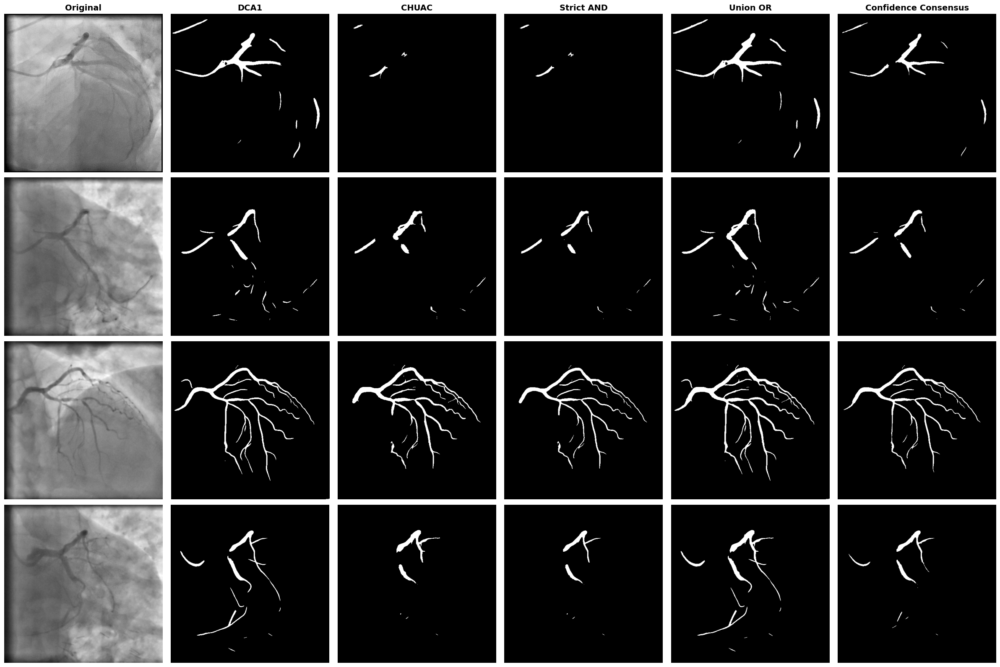

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# SETTINGS
# ============================================================

STANDARD_THRESHOLD = 0.5
HIGH_CONFIDENCE_THRESHOLD = 0.90


# ============================================================
# DUAL-MODEL INFERENCE
# ============================================================

def dual_model_inference(img):

    input_tensor_local = prepare_image_for_model(img)

    model.eval()
    model_chuac.eval()

    with torch.no_grad():

        # DCA1
        logits_dca1 = model(input_tensor_local)

        if isinstance(logits_dca1, (tuple, list)):
            logits_dca1 = logits_dca1[-1]

        prob_dca1 = torch.sigmoid(logits_dca1)

        # CHUAC
        logits_chuac = model_chuac(input_tensor_local)

        if isinstance(logits_chuac, (tuple, list)):
            logits_chuac = logits_chuac[-1]

        prob_chuac = torch.sigmoid(logits_chuac)

    prob_dca1 = (
        prob_dca1[0, 0]
        .detach()
        .cpu()
        .numpy()
    )

    prob_chuac = (
        prob_chuac[0, 0]
        .detach()
        .cpu()
        .numpy()
    )

    return prob_dca1, prob_chuac


# ============================================================
# RUN ON FOUR REPRESENTATIVE IMAGES
# ============================================================

consensus_results = {}

for category in categories:

    img = sample_images[category]["image"]

    prob_dca1, prob_chuac = dual_model_inference(img)

    # Standard masks
    mask_dca1 = (
        prob_dca1 >= STANDARD_THRESHOLD
    ).astype(np.uint8)

    mask_chuac = (
        prob_chuac >= STANDARD_THRESHOLD
    ).astype(np.uint8)

    # --------------------------------------------------------
    # Method 1: Strict agreement
    # Both models must predict vessel
    # --------------------------------------------------------

    strict_and = np.logical_and(
        mask_dca1,
        mask_chuac
    ).astype(np.uint8)

    # --------------------------------------------------------
    # Method 2: Union
    # Either model predicts vessel
    # --------------------------------------------------------

    union_or = np.logical_or(
        mask_dca1,
        mask_chuac
    ).astype(np.uint8)

    # --------------------------------------------------------
    # Method 3: Confidence-aware consensus
    # Agreement OR very high confidence from either model
    # --------------------------------------------------------

    agreement = np.logical_and(
        prob_dca1 >= STANDARD_THRESHOLD,
        prob_chuac >= STANDARD_THRESHOLD
    )

    dca1_very_confident = (
        prob_dca1 >= HIGH_CONFIDENCE_THRESHOLD
    )

    chuac_very_confident = (
        prob_chuac >= HIGH_CONFIDENCE_THRESHOLD
    )

    confidence_consensus = np.logical_or.reduce([
        agreement,
        dca1_very_confident,
        chuac_very_confident
    ]).astype(np.uint8)

    consensus_results[category] = {
        "image": img,
        "dca1": mask_dca1,
        "chuac": mask_chuac,
        "strict_and": strict_and,
        "union_or": union_or,
        "confidence_consensus": confidence_consensus
    }

    print("\n" + "=" * 70)
    print(category)
    print("=" * 70)

    print(
        f"DCA1 coverage               : "
        f"{mask_dca1.mean() * 100:.2f}%"
    )

    print(
        f"CHUAC coverage              : "
        f"{mask_chuac.mean() * 100:.2f}%"
    )

    print(
        f"Strict AND coverage         : "
        f"{strict_and.mean() * 100:.2f}%"
    )

    print(
        f"Union OR coverage           : "
        f"{union_or.mean() * 100:.2f}%"
    )

    print(
        f"Confidence consensus        : "
        f"{confidence_consensus.mean() * 100:.2f}%"
    )


# ============================================================
# DISPLAY COMPARISON
# ============================================================

fig, axes = plt.subplots(
    len(categories),
    6,
    figsize=(24, 16)
)

column_titles = [
    "Original",
    "DCA1",
    "CHUAC",
    "Strict AND",
    "Union OR",
    "Confidence Consensus"
]

for col, title in enumerate(column_titles):
    axes[0, col].set_title(
        title,
        fontsize=14,
        fontweight="bold"
    )

for row, category in enumerate(categories):

    result = consensus_results[category]

    images_to_show = [
        result["image"],
        result["dca1"],
        result["chuac"],
        result["strict_and"],
        result["union_or"],
        result["confidence_consensus"]
    ]

    for col, display_img in enumerate(images_to_show):

        if col == 0:
            axes[row, col].imshow(
                display_img,
                cmap="gray"
            )
        else:
            axes[row, col].imshow(
                display_img,
                cmap="gray",
                vmin=0,
                vmax=1
            )

        axes[row, col].axis("off")

    axes[row, 0].set_ylabel(
        category,
        fontsize=12,
        fontweight="bold"
    )

plt.tight_layout()
plt.show()

In [ ]:
import os
import cv2
import torch
import numpy as np
import pandas as pd
from tqdm.auto import tqdm

# ============================================================
# PATHS
# ============================================================

FINETUNE_ROOT = (
    "/content/drive/MyDrive/angio_ai_project/"
    "AngioLens_FineTuning_200"
)

IMAGES_ROOT = os.path.join(
    FINETUNE_ROOT,
    "images"
)

# ============================================================
# CATEGORIES
# ============================================================

categories = [
    "Normal",
    "Post-treatment",
    "Pre-treatment",
    "Unique Stenosis Views"
]

# ============================================================
# THRESHOLDS
# ============================================================

STANDARD_THRESHOLD = 0.5
HIGH_CONFIDENCE_THRESHOLD = 0.90


# ============================================================
# DUAL-MODEL INFERENCE
# ============================================================

def get_dual_model_probabilities(img):

    input_tensor_local = prepare_image_for_model(img)

    model.eval()
    model_chuac.eval()

    with torch.no_grad():

        # -------------------------
        # DCA1
        # -------------------------

        logits_dca1 = model(input_tensor_local)

        if isinstance(logits_dca1, (tuple, list)):
            logits_dca1 = logits_dca1[-1]

        prob_dca1 = torch.sigmoid(
            logits_dca1
        )[0, 0].detach().cpu().numpy()

        # -------------------------
        # CHUAC
        # -------------------------

        logits_chuac = model_chuac(
            input_tensor_local
        )

        if isinstance(logits_chuac, (tuple, list)):
            logits_chuac = logits_chuac[-1]

        prob_chuac = torch.sigmoid(
            logits_chuac
        )[0, 0].detach().cpu().numpy()

    return prob_dca1, prob_chuac


# ============================================================
# ANALYZE ALL 200 IMAGES
# ============================================================

all_results = []

for category in categories:

    print("\n" + "=" * 70)
    print(f"Analyzing category: {category}")
    print("=" * 70)

    image_folder = os.path.join(
        IMAGES_ROOT,
        category
    )

    image_files = sorted([
        filename
        for filename in os.listdir(image_folder)
        if filename.lower().endswith(
            (".png", ".jpg", ".jpeg")
        )
    ])

    for filename in tqdm(
        image_files,
        desc=category
    ):

        image_path = os.path.join(
            image_folder,
            filename
        )

        img = cv2.imread(
            image_path,
            cv2.IMREAD_GRAYSCALE
        )

        if img is None:
            print(
                f"Could not read: {filename}"
            )
            continue

        # ----------------------------------------
        # Run both models
        # ----------------------------------------

        prob_dca1, prob_chuac = (
            get_dual_model_probabilities(img)
        )

        # ----------------------------------------
        # Standard binary masks
        # ----------------------------------------

        mask_dca1 = (
            prob_dca1 >= STANDARD_THRESHOLD
        )

        mask_chuac = (
            prob_chuac >= STANDARD_THRESHOLD
        )

        # ----------------------------------------
        # Intersection and Union
        # ----------------------------------------

        intersection = np.logical_and(
            mask_dca1,
            mask_chuac
        )

        union = np.logical_or(
            mask_dca1,
            mask_chuac
        )

        # ----------------------------------------
        # IoU between DCA1 and CHUAC
        # ----------------------------------------

        intersection_pixels = (
            intersection.sum()
        )

        union_pixels = union.sum()

        if union_pixels > 0:

            iou = (
                intersection_pixels /
                union_pixels
            )

        else:

            iou = 0.0

        # ----------------------------------------
        # Dice agreement
        # ----------------------------------------

        total_positive_pixels = (
            mask_dca1.sum() +
            mask_chuac.sum()
        )

        if total_positive_pixels > 0:

            dice_agreement = (
                2.0 *
                intersection_pixels /
                total_positive_pixels
            )

        else:

            dice_agreement = 0.0

        # ----------------------------------------
        # Confidence-aware consensus
        # ----------------------------------------

        high_conf_dca1 = (
            prob_dca1 >=
            HIGH_CONFIDENCE_THRESHOLD
        )

        high_conf_chuac = (
            prob_chuac >=
            HIGH_CONFIDENCE_THRESHOLD
        )

        confidence_consensus = (
            intersection |
            high_conf_dca1 |
            high_conf_chuac
        )

        # ----------------------------------------
        # Coverage
        # ----------------------------------------

        dca1_coverage = (
            mask_dca1.mean() * 100
        )

        chuac_coverage = (
            mask_chuac.mean() * 100
        )

        strict_and_coverage = (
            intersection.mean() * 100
        )

        consensus_coverage = (
            confidence_consensus.mean() * 100
        )

        # ----------------------------------------
        # Mean confidence inside consensus
        # ----------------------------------------

        if confidence_consensus.sum() > 0:

            combined_probability = (
                prob_dca1 +
                prob_chuac
            ) / 2.0

            mean_consensus_confidence = (
                combined_probability[
                    confidence_consensus
                ].mean()
            )

        else:

            mean_consensus_confidence = 0.0

        # ----------------------------------------
        # Save result
        # ----------------------------------------

        all_results.append({

            "Category":
                category,

            "Filename":
                filename,

            "DCA1_Coverage":
                float(dca1_coverage),

            "CHUAC_Coverage":
                float(chuac_coverage),

            "Strict_AND_Coverage":
                float(strict_and_coverage),

            "Consensus_Coverage":
                float(consensus_coverage),

            "IoU_Agreement":
                float(iou),

            "Dice_Agreement":
                float(dice_agreement),

            "Mean_Consensus_Confidence":
                float(mean_consensus_confidence)
        })


# ============================================================
# CREATE DATAFRAME
# ============================================================

results_df = pd.DataFrame(
    all_results
)

print("\n" + "=" * 70)
print("ANALYSIS COMPLETED")
print("=" * 70)

print(
    f"Total analyzed images: "
    f"{len(results_df)}"
)


# ============================================================
# SAVE FULL RESULTS
# ============================================================

results_csv_path = os.path.join(
    FINETUNE_ROOT,
    "dual_model_analysis_200.csv"
)

results_df.to_csv(
    results_csv_path,
    index=False
)

print(
    f"\nFull analysis saved to:\n"
    f"{results_csv_path}"
)


# ============================================================
# SUMMARY PER CATEGORY
# ============================================================

print("\n" + "=" * 70)
print("MEAN RESULTS PER CATEGORY")
print("=" * 70)

summary = results_df.groupby(
    "Category"
)[[
    "DCA1_Coverage",
    "CHUAC_Coverage",
    "Strict_AND_Coverage",
    "Consensus_Coverage",
    "IoU_Agreement",
    "Dice_Agreement",
    "Mean_Consensus_Confidence"
]].mean()

print(
    summary.round(4).to_string()
)


Analyzing category: Normal


Normal:   0%|          | 0/50 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
import os
import shutil
import pandas as pd
import numpy as np

# ============================================================
# PATHS
# ============================================================

FINETUNE_ROOT = (
    "/content/drive/MyDrive/angio_ai_project/"
    "AngioLens_FineTuning_200"
)

IMAGES_ROOT = os.path.join(
    FINETUNE_ROOT,
    "images"
)

CSV_PATH = os.path.join(
    FINETUNE_ROOT,
    "dual_model_analysis_200.csv"
)

SELECTED_ROOT = os.path.join(
    FINETUNE_ROOT,
    "Consensus_Selected_100"
)

SELECTED_IMAGES_ROOT = os.path.join(
    SELECTED_ROOT,
    "images"
)

# ============================================================
# SETTINGS
# ============================================================

categories = [
    "Normal",
    "Post-treatment",
    "Pre-treatment",
    "Unique Stenosis Views"
]

NUM_PER_CATEGORY = 25

# ============================================================
# LOAD ANALYSIS
# ============================================================

df = pd.read_csv(CSV_PATH)

print("Total records loaded:", len(df))

# ============================================================
# CALCULATE QUALITY SCORE PER CATEGORY
# ============================================================

selected_dfs = []

for category in categories:

    category_df = df[
        df["Category"] == category
    ].copy()

    # --------------------------------------------------------
    # Normalize Consensus Coverage within this category
    # --------------------------------------------------------

    coverage_min = category_df[
        "Consensus_Coverage"
    ].min()

    coverage_max = category_df[
        "Consensus_Coverage"
    ].max()

    if coverage_max > coverage_min:

        category_df[
            "Normalized_Coverage"
        ] = (
            category_df["Consensus_Coverage"]
            - coverage_min
        ) / (
            coverage_max
            - coverage_min
        )

    else:

        category_df[
            "Normalized_Coverage"
        ] = 0.0

    # --------------------------------------------------------
    # Composite Quality Score
    # --------------------------------------------------------

    category_df[
        "Quality_Score"
    ] = (

        0.45
        * category_df["IoU_Agreement"]

        +

        0.35
        * category_df[
            "Mean_Consensus_Confidence"
        ]

        +

        0.20
        * category_df[
            "Normalized_Coverage"
        ]
    )

    # --------------------------------------------------------
    # Select top 25
    # --------------------------------------------------------

    selected_category = (
        category_df
        .sort_values(
            by="Quality_Score",
            ascending=False
        )
        .head(NUM_PER_CATEGORY)
        .copy()
    )

    selected_dfs.append(
        selected_category
    )

# ============================================================
# COMBINE SELECTED IMAGES
# ============================================================

selected_df = pd.concat(
    selected_dfs,
    ignore_index=True
)

# ============================================================
# COPY SELECTED IMAGES
# ============================================================

for category in categories:

    source_folder = os.path.join(
        IMAGES_ROOT,
        category
    )

    destination_folder = os.path.join(
        SELECTED_IMAGES_ROOT,
        category
    )

    os.makedirs(
        destination_folder,
        exist_ok=True
    )

    category_selected = selected_df[
        selected_df["Category"] == category
    ]

    for _, row in category_selected.iterrows():

        filename = row["Filename"]

        source_path = os.path.join(
            source_folder,
            filename
        )

        destination_path = os.path.join(
            destination_folder,
            filename
        )

        shutil.copy2(
            source_path,
            destination_path
        )

# ============================================================
# SAVE SELECTED RESULTS
# ============================================================

selected_csv_path = os.path.join(
    SELECTED_ROOT,
    "selected_100_quality_scores.csv"
)

os.makedirs(
    SELECTED_ROOT,
    exist_ok=True
)

selected_df.to_csv(
    selected_csv_path,
    index=False
)

# ============================================================
# FINAL SUMMARY
# ============================================================

print("\n" + "=" * 70)
print("CONSENSUS-BASED SELECTION COMPLETED")
print("=" * 70)

total = 0

for category in categories:

    category_selected = selected_df[
        selected_df["Category"] == category
    ]

    count = len(category_selected)

    total += count

    print(f"\n{category}")
    print(f"  Selected images : {count}")

    print(
        f"  Mean IoU        : "
        f"{category_selected['IoU_Agreement'].mean():.4f}"
    )

    print(
        f"  Mean Dice       : "
        f"{category_selected['Dice_Agreement'].mean():.4f}"
    )

    print(
        f"  Mean Confidence : "
        f"{category_selected['Mean_Consensus_Confidence'].mean():.4f}"
    )

    print(
        f"  Mean Coverage   : "
        f"{category_selected['Consensus_Coverage'].mean():.2f}%"
    )

    print(
        f"  Mean Quality    : "
        f"{category_selected['Quality_Score'].mean():.4f}"
    )

print("\n" + "-" * 70)
print(f"Total selected images: {total}")

print("\nSelected images saved to:")
print(SELECTED_IMAGES_ROOT)

print("\nSelection CSV saved to:")
print(selected_csv_path)

In [ ]:
import os
import cv2
import torch
import numpy as np
from tqdm.auto import tqdm

# ============================================================
# PATHS
# ============================================================

FINETUNE_ROOT = (
    "/content/drive/MyDrive/angio_ai_project/"
    "AngioLens_FineTuning_200"
)

SELECTED_ROOT = os.path.join(
    FINETUNE_ROOT,
    "Consensus_Selected_100"
)

SELECTED_IMAGES_ROOT = os.path.join(
    SELECTED_ROOT,
    "images"
)

FINAL_MASKS_ROOT = os.path.join(
    SELECTED_ROOT,
    "final_consensus_masks"
)

# ============================================================
# SETTINGS
# ============================================================

categories = [
    "Normal",
    "Post-treatment",
    "Pre-treatment",
    "Unique Stenosis Views"
]

STANDARD_THRESHOLD = 0.5
HIGH_CONFIDENCE_THRESHOLD = 0.90

# ============================================================
# GENERATE FINAL CONSENSUS MASKS
# ============================================================

generation_summary = {}

for category in categories:

    print("\n" + "=" * 70)
    print(f"Generating final consensus masks: {category}")
    print("=" * 70)

    image_folder = os.path.join(
        SELECTED_IMAGES_ROOT,
        category
    )

    output_folder = os.path.join(
        FINAL_MASKS_ROOT,
        category
    )

    os.makedirs(
        output_folder,
        exist_ok=True
    )

    image_files = sorted([
        filename
        for filename in os.listdir(image_folder)
        if filename.lower().endswith(
            (".png", ".jpg", ".jpeg")
        )
    ])

    generated_count = 0
    failed_count = 0
    coverages = []

    for filename in tqdm(
        image_files,
        desc=category
    ):

        image_path = os.path.join(
            image_folder,
            filename
        )

        img = cv2.imread(
            image_path,
            cv2.IMREAD_GRAYSCALE
        )

        if img is None:

            print(f"Could not read: {filename}")
            failed_count += 1
            continue

        try:

            # ----------------------------------------
            # Get probabilities from both models
            # ----------------------------------------

            prob_dca1, prob_chuac = (
                get_dual_model_probabilities(img)
            )

            # ----------------------------------------
            # Standard predictions
            # ----------------------------------------

            dca1_standard = (
                prob_dca1 >= STANDARD_THRESHOLD
            )

            chuac_standard = (
                prob_chuac >= STANDARD_THRESHOLD
            )

            # ----------------------------------------
            # Agreement
            # ----------------------------------------

            agreement = np.logical_and(
                dca1_standard,
                chuac_standard
            )

            # ----------------------------------------
            # Very high-confidence predictions
            # ----------------------------------------

            dca1_high_confidence = (
                prob_dca1 >= HIGH_CONFIDENCE_THRESHOLD
            )

            chuac_high_confidence = (
                prob_chuac >= HIGH_CONFIDENCE_THRESHOLD
            )

            # ----------------------------------------
            # Final consensus
            # ----------------------------------------

            final_consensus = np.logical_or.reduce([
                agreement,
                dca1_high_confidence,
                chuac_high_confidence
            ]).astype(np.uint8)

            # ----------------------------------------
            # Save as binary mask: 0 / 255
            # ----------------------------------------

            mask_to_save = (
                final_consensus * 255
            ).astype(np.uint8)

            output_path = os.path.join(
                output_folder,
                filename
            )

            success = cv2.imwrite(
                output_path,
                mask_to_save
            )

            if success:

                generated_count += 1

                coverage = (
                    final_consensus.mean() * 100
                )

                coverages.append(coverage)

            else:

                failed_count += 1

        except Exception as e:

            print(
                f"\nError with {filename}: {e}"
            )

            failed_count += 1

    # ----------------------------------------
    # Save summary
    # ----------------------------------------

    generation_summary[category] = {

        "generated": generated_count,

        "failed": failed_count,

        "mean_coverage": (
            float(np.mean(coverages))
            if coverages else 0.0
        ),

        "min_coverage": (
            float(np.min(coverages))
            if coverages else 0.0
        ),

        "max_coverage": (
            float(np.max(coverages))
            if coverages else 0.0
        )
    }


# ============================================================
# FINAL SUMMARY
# ============================================================

print("\n" + "=" * 70)
print("FINAL CONSENSUS MASK GENERATION SUMMARY")
print("=" * 70)

total_generated = 0
total_failed = 0

for category in categories:

    stats = generation_summary[category]

    total_generated += stats["generated"]
    total_failed += stats["failed"]

    print(f"\n{category}")

    print(
        f"  Generated     : "
        f"{stats['generated']}"
    )

    print(
        f"  Failed        : "
        f"{stats['failed']}"
    )

    print(
        f"  Mean coverage : "
        f"{stats['mean_coverage']:.2f}%"
    )

    print(
        f"  Min coverage  : "
        f"{stats['min_coverage']:.2f}%"
    )

    print(
        f"  Max coverage  : "
        f"{stats['max_coverage']:.2f}%"
    )

print("\n" + "-" * 70)

print(
    f"Total generated consensus masks: "
    f"{total_generated}"
)

print(
    f"Total failed: "
    f"{total_failed}"
)

print(
    "\nSaved to:\n"
    f"{FINAL_MASKS_ROOT}"
)

In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# PATHS
# ============================================================

FINETUNE_ROOT = (
    "/content/drive/MyDrive/angio_ai_project/"
    "AngioLens_FineTuning_200"
)

SELECTED_ROOT = os.path.join(
    FINETUNE_ROOT,
    "Consensus_Selected_100"
)

IMAGES_ROOT = os.path.join(
    SELECTED_ROOT,
    "images"
)

MASKS_ROOT = os.path.join(
    SELECTED_ROOT,
    "final_consensus_masks"
)

# ============================================================
# SETTINGS
# ============================================================

categories = [
    "Normal",
    "Post-treatment",
    "Pre-treatment",
    "Unique Stenosis Views"
]

NUM_SAMPLES = 5


# ============================================================
# PROCESS EACH CATEGORY
# ============================================================

for category in categories:

    image_folder = os.path.join(
        IMAGES_ROOT,
        category
    )

    mask_folder = os.path.join(
        MASKS_ROOT,
        category
    )

    filenames = sorted([
        f for f in os.listdir(image_folder)
        if f.lower().endswith((".png", ".jpg", ".jpeg"))
    ])

    # --------------------------------------------------------
    # Calculate coverage for every mask
    # --------------------------------------------------------

    records = []

    for filename in filenames:

        mask_path = os.path.join(
            mask_folder,
            filename
        )

        mask = cv2.imread(
            mask_path,
            cv2.IMREAD_GRAYSCALE
        )

        if mask is None:
            continue

        binary_mask = mask > 127

        coverage = (
            binary_mask.mean() * 100
        )

        records.append({
            "filename": filename,
            "coverage": coverage
        })

    # Sort from lowest to highest coverage
    records = sorted(
        records,
        key=lambda x: x["coverage"]
    )

    # --------------------------------------------------------
    # Select 5 representative positions
    # --------------------------------------------------------

    indices = np.linspace(
        0,
        len(records) - 1,
        NUM_SAMPLES
    ).astype(int)

    selected_records = [
        records[i] for i in indices
    ]

    # --------------------------------------------------------
    # Plot
    # --------------------------------------------------------

    fig, axes = plt.subplots(
        NUM_SAMPLES,
        3,
        figsize=(15, 5 * NUM_SAMPLES)
    )

    fig.suptitle(
        f"Final Consensus Mask Quality Review — {category}",
        fontsize=18,
        fontweight="bold",
        y=0.995
    )

    print("\n" + "=" * 70)
    print(category)
    print("=" * 70)

    for row, record in enumerate(selected_records):

        filename = record["filename"]
        coverage = record["coverage"]

        image_path = os.path.join(
            image_folder,
            filename
        )

        mask_path = os.path.join(
            mask_folder,
            filename
        )

        image = cv2.imread(
            image_path,
            cv2.IMREAD_GRAYSCALE
        )

        mask = cv2.imread(
            mask_path,
            cv2.IMREAD_GRAYSCALE
        )

        binary_mask = mask > 127

        # ----------------------------------------
        # Create red overlay
        # ----------------------------------------

        image_rgb = cv2.cvtColor(
            image,
            cv2.COLOR_GRAY2RGB
        )

        overlay = image_rgb.copy()

        overlay[binary_mask] = [255, 0, 0]

        blended = cv2.addWeighted(
            image_rgb,
            0.75,
            overlay,
            0.25,
            0
        )

        # ----------------------------------------
        # Original
        # ----------------------------------------

        axes[row, 0].imshow(
            image,
            cmap="gray"
        )

        axes[row, 0].set_title(
            f"Original — Sample {row + 1}"
        )

        axes[row, 0].axis("off")

        # ----------------------------------------
        # Mask
        # ----------------------------------------

        axes[row, 1].imshow(
            binary_mask,
            cmap="gray"
        )

        axes[row, 1].set_title(
            f"Final Consensus Mask — {coverage:.2f}%"
        )

        axes[row, 1].axis("off")

        # ----------------------------------------
        # Overlay
        # ----------------------------------------

        axes[row, 2].imshow(blended)

        axes[row, 2].set_title(
            "Final Consensus Overlay"
        )

        axes[row, 2].axis("off")

        print(
            f"Sample {row + 1}: "
            f"{filename} | "
            f"Coverage = {coverage:.2f}%"
        )

    plt.tight_layout(
        rect=[0, 0, 1, 0.985]
    )

    plt.show()

In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

# ============================================================
# PATHS
# ============================================================

FINETUNE_ROOT = (
    "/content/drive/MyDrive/angio_ai_project/"
    "AngioLens_FineTuning_200"
)

SELECTED_ROOT = os.path.join(
    FINETUNE_ROOT,
    "Consensus_Selected_100"
)

IMAGES_ROOT = os.path.join(
    SELECTED_ROOT,
    "images"
)

MASKS_ROOT = os.path.join(
    SELECTED_ROOT,
    "final_consensus_masks"
)

CLEAN_MASKS_ROOT = os.path.join(
    SELECTED_ROOT,
    "clean_consensus_masks"
)

categories = [
    "Normal",
    "Post-treatment",
    "Pre-treatment",
    "Unique Stenosis Views"
]

# ============================================================
# CONSERVATIVE AUTOMATIC FILTER
# ============================================================

def clean_consensus_mask(mask):
    """
    Removes only components that strongly resemble catheter/wire artifacts.
    The filter is intentionally conservative.
    """

    mask = (mask > 127).astype(np.uint8)

    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(
        mask,
        connectivity=8
    )

    cleaned = np.zeros_like(mask)

    H, W = mask.shape
    image_diag = np.sqrt(H**2 + W**2)

    for label_id in range(1, num_labels):

        component = (labels == label_id).astype(np.uint8)

        area = stats[label_id, cv2.CC_STAT_AREA]
        x = stats[label_id, cv2.CC_STAT_LEFT]
        y = stats[label_id, cv2.CC_STAT_TOP]
        w = stats[label_id, cv2.CC_STAT_WIDTH]
        h = stats[label_id, cv2.CC_STAT_HEIGHT]

        # Ignore tiny isolated noise
        if area < 25:
            continue

        # ----------------------------------------------------
        # Component geometry
        # ----------------------------------------------------

        component_length = np.sqrt(w**2 + h**2)
        elongation = max(w, h) / max(1, min(w, h))

        touches_border = (
            x <= 2 or
            y <= 2 or
            x + w >= W - 2 or
            y + h >= H - 2
        )

        long_component = (
            component_length >= 0.45 * image_diag
        )

        very_elongated = (
            elongation >= 8.0
        )

        # Thinness estimate:
        # low area compared with bounding-box length
        thin_component = (
            area / max(component_length, 1) < 18
        )

        # Remove only when several artifact clues agree
        likely_catheter_or_wire = (
            touches_border
            and long_component
            and very_elongated
            and thin_component
        )

        if likely_catheter_or_wire:
            continue

        cleaned[component == 1] = 1

    # Mild closing to reconnect tiny vessel gaps
    kernel_close = cv2.getStructuringElement(
        cv2.MORPH_ELLIPSE,
        (3, 3)
    )

    cleaned = cv2.morphologyEx(
        cleaned,
        cv2.MORPH_CLOSE,
        kernel_close
    )

    return cleaned.astype(np.uint8)


# ============================================================
# CLEAN ALL 100 MASKS
# ============================================================

summary = {}

for category in categories:

    print("\n" + "=" * 70)
    print("Cleaning:", category)
    print("=" * 70)

    source_folder = os.path.join(
        MASKS_ROOT,
        category
    )

    output_folder = os.path.join(
        CLEAN_MASKS_ROOT,
        category
    )

    os.makedirs(
        output_folder,
        exist_ok=True
    )

    files = sorted([
        f for f in os.listdir(source_folder)
        if f.lower().endswith(".png")
    ])

    before_coverages = []
    after_coverages = []
    cleaned_count = 0

    for filename in tqdm(files, desc=category):

        mask_path = os.path.join(
            source_folder,
            filename
        )

        mask = cv2.imread(
            mask_path,
            cv2.IMREAD_GRAYSCALE
        )

        if mask is None:
            continue

        binary_before = (mask > 127).astype(np.uint8)

        cleaned = clean_consensus_mask(mask)

        output_path = os.path.join(
            output_folder,
            filename
        )

        cv2.imwrite(
            output_path,
            cleaned * 255
        )

        before_coverages.append(
            binary_before.mean() * 100
        )

        after_coverages.append(
            cleaned.mean() * 100
        )

        if not np.array_equal(binary_before, cleaned):
            cleaned_count += 1

    summary[category] = {
        "total": len(files),
        "changed": cleaned_count,
        "before_mean": float(np.mean(before_coverages)),
        "after_mean": float(np.mean(after_coverages))
    }


# ============================================================
# SUMMARY
# ============================================================

print("\n" + "=" * 70)
print("AUTOMATIC CLEANING SUMMARY")
print("=" * 70)

for category in categories:

    s = summary[category]

    print(f"\n{category}")
    print(f"  Total masks       : {s['total']}")
    print(f"  Changed masks     : {s['changed']}")
    print(f"  Mean before       : {s['before_mean']:.2f}%")
    print(f"  Mean after        : {s['after_mean']:.2f}%")

print("\nSaved to:")
print(CLEAN_MASKS_ROOT)


Cleaning: Normal


Normal:   0%|          | 0/25 [00:00<?, ?it/s]


Cleaning: Post-treatment


Post-treatment:   0%|          | 0/25 [00:00<?, ?it/s]


Cleaning: Pre-treatment


Pre-treatment:   0%|          | 0/25 [00:00<?, ?it/s]


Cleaning: Unique Stenosis Views


Unique Stenosis Views:   0%|          | 0/25 [00:00<?, ?it/s]


AUTOMATIC CLEANING SUMMARY

Normal
  Total masks       : 25
  Changed masks     : 25
  Mean before       : 3.15%
  Mean after        : 3.10%

Post-treatment
  Total masks       : 25
  Changed masks     : 25
  Mean before       : 2.38%
  Mean after        : 2.35%

Pre-treatment
  Total masks       : 25
  Changed masks     : 25
  Mean before       : 3.24%
  Mean after        : 3.23%

Unique Stenosis Views
  Total masks       : 25
  Changed masks     : 25
  Mean before       : 3.22%
  Mean after        : 3.22%

Saved to:
/content/drive/MyDrive/angio_ai_project/AngioLens_FineTuning_200/Consensus_Selected_100/clean_consensus_masks


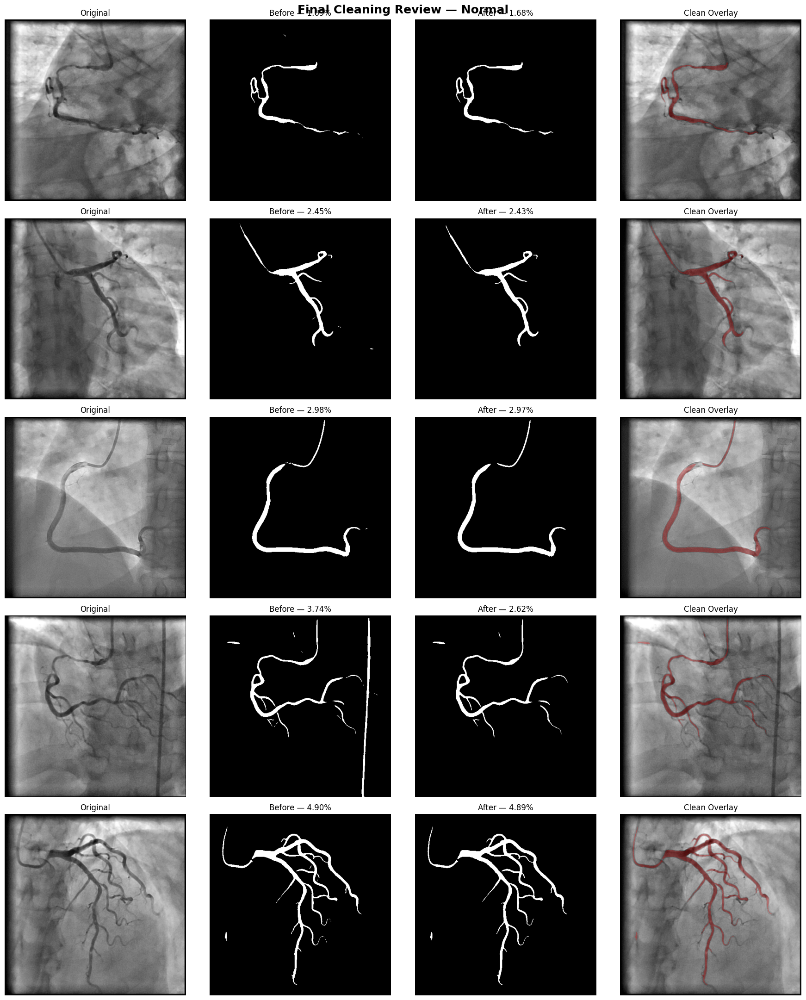

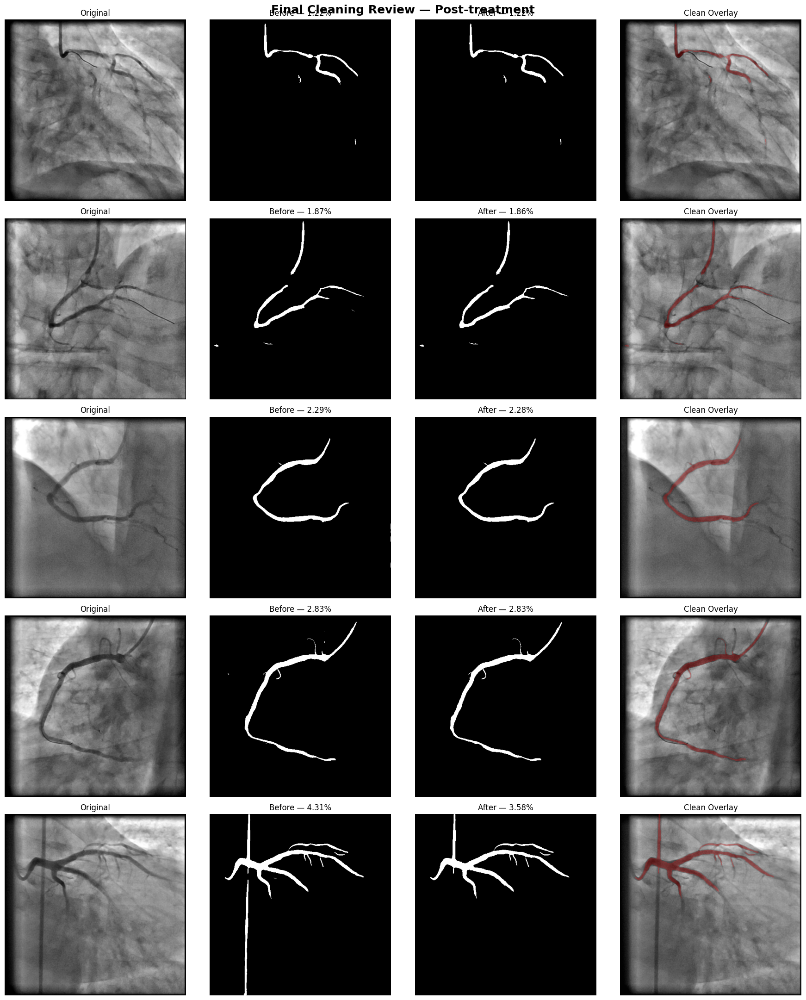

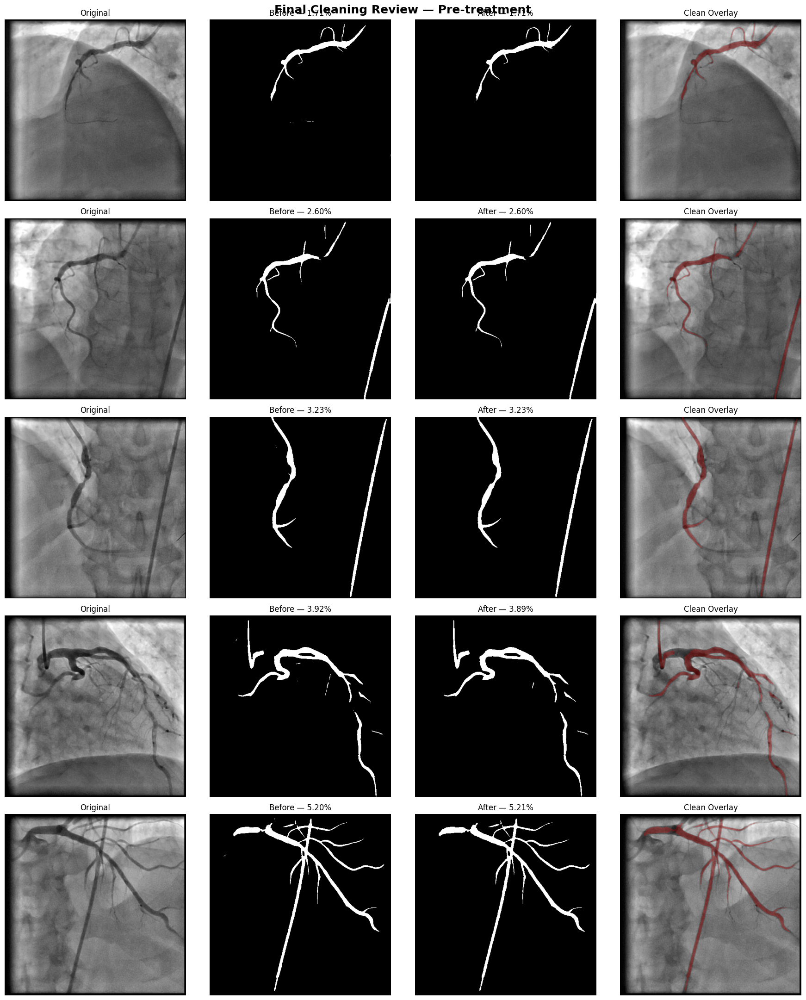

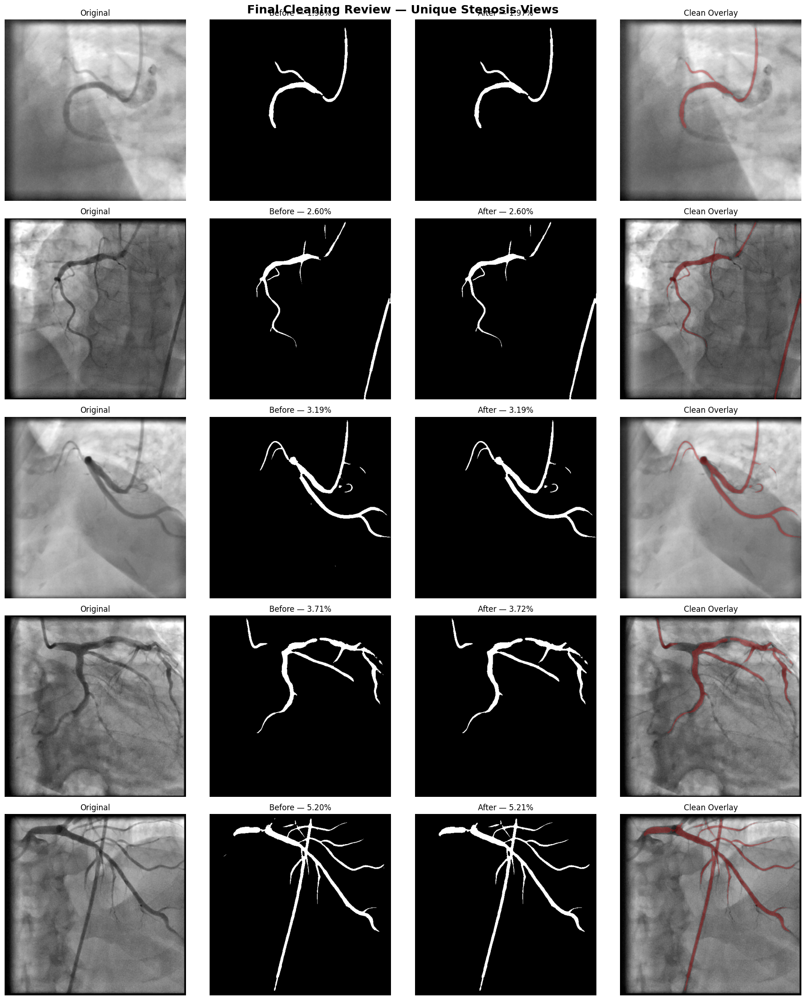

In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

for category in categories:

    image_folder = os.path.join(
        IMAGES_ROOT,
        category
    )

    before_folder = os.path.join(
        MASKS_ROOT,
        category
    )

    after_folder = os.path.join(
        CLEAN_MASKS_ROOT,
        category
    )

    filenames = sorted([
        f for f in os.listdir(image_folder)
        if f.lower().endswith(".png")
    ])

    records = []

    for filename in filenames:

        before = cv2.imread(
            os.path.join(before_folder, filename),
            cv2.IMREAD_GRAYSCALE
        )

        if before is None:
            continue

        coverage = (before > 127).mean() * 100

        records.append({
            "filename": filename,
            "coverage": coverage
        })

    records = sorted(
        records,
        key=lambda x: x["coverage"]
    )

    indices = np.linspace(
        0,
        len(records) - 1,
        5,
        dtype=int
    )

    selected = [records[i] for i in indices]

    fig, axes = plt.subplots(
        5,
        4,
        figsize=(18, 22)
    )

    fig.suptitle(
        f"Final Cleaning Review — {category}",
        fontsize=18,
        fontweight="bold"
    )

    for row, record in enumerate(selected):

        filename = record["filename"]

        image = cv2.imread(
            os.path.join(image_folder, filename),
            cv2.IMREAD_GRAYSCALE
        )

        before = cv2.imread(
            os.path.join(before_folder, filename),
            cv2.IMREAD_GRAYSCALE
        )

        after = cv2.imread(
            os.path.join(after_folder, filename),
            cv2.IMREAD_GRAYSCALE
        )

        before_bin = before > 127
        after_bin = after > 127

        image_rgb = cv2.cvtColor(
            image,
            cv2.COLOR_GRAY2RGB
        )

        overlay = image_rgb.copy()
        overlay[after_bin] = [255, 0, 0]

        blended = cv2.addWeighted(
            image_rgb,
            0.75,
            overlay,
            0.25,
            0
        )

        axes[row, 0].imshow(image, cmap="gray")
        axes[row, 0].set_title("Original")

        axes[row, 1].imshow(before_bin, cmap="gray")
        axes[row, 1].set_title(
            f"Before — {before_bin.mean()*100:.2f}%"
        )

        axes[row, 2].imshow(after_bin, cmap="gray")
        axes[row, 2].set_title(
            f"After — {after_bin.mean()*100:.2f}%"
        )

        axes[row, 3].imshow(blended)
        axes[row, 3].set_title("Clean Overlay")

        for col in range(4):
            axes[row, col].axis("off")

    plt.tight_layout()
    plt.show()

In [ ]:
print("DCA1 model:", type(model))
print("CHUAC model:", type(model_chuac))
print("Device:", device)

DCA1 model: <class 'models.fr_unet.FR_UNet'>
CHUAC model: <class 'models.fr_unet.FR_UNet'>
Device: cuda


In [ ]:
# ============================================================
# ANGIOLENS — FULL DUAL-MODEL CONSENSUS PIPELINE
# DCA1 + CHUAC → Consensus Mask → Accepted / Rejected
# ============================================================

import os
import gc
import cv2
import torch
import numpy as np
import pandas as pd

from pathlib import Path
from tqdm.auto import tqdm


# ============================================================
# 1. CHECK MODELS AND DEVICE
# ============================================================

required_variables = ["model", "model_chuac", "device"]

missing_variables = [
    variable_name
    for variable_name in required_variables
    if variable_name not in globals()
]

if missing_variables:
    raise RuntimeError(
        "المتغيرات التالية غير موجودة في الـ Runtime: "
        + ", ".join(missing_variables)
        + "\nشغّلي خلايا تحميل DCA1 وCHUAC أولًا."
    )

model = model.to(device)
model_chuac = model_chuac.to(device)

model.eval()
model_chuac.eval()

print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


# ============================================================
# 2. PATHS
# ============================================================

DATA_ROOT = Path(
    "/content/drive/MyDrive/angio_ai_project/data/AngioLens_Data"
)

OUTPUT_ROOT = Path(
    "/content/drive/MyDrive/angio_ai_project/"
    "AngioLens_Final_PseudoLabels"
)

ALL_MASKS_ROOT = OUTPUT_ROOT / "all_consensus_masks"

ACCEPTED_MASKS_ROOT = OUTPUT_ROOT / "accepted" / "masks"
ACCEPTED_IMAGES_ROOT = OUTPUT_ROOT / "accepted" / "images"

REJECTED_MASKS_ROOT = OUTPUT_ROOT / "rejected" / "masks"
REJECTED_IMAGES_ROOT = OUTPUT_ROOT / "rejected" / "images"

CSV_PATH = OUTPUT_ROOT / "pseudo_label_quality_results.csv"
ERRORS_CSV_PATH = OUTPUT_ROOT / "processing_errors.csv"

OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)


# ============================================================
# 3. DATASET CATEGORIES
# ============================================================

CATEGORIES = [
    "Normal",
    "Post-treatment",
    "Pre-treatment",
    "Unique Stenosis Views"
]


# ============================================================
# 4. INFERENCE AND ACCEPTANCE SETTINGS
# ============================================================

INFERENCE_SIZE = 512

STANDARD_THRESHOLD = 0.50
HIGH_CONFIDENCE_THRESHOLD = 0.90

MIN_IOU = 0.50
MIN_CONFIDENCE = 0.80
MIN_QUALITY = 0.60

MIN_COVERAGE = 1.00
MAX_COVERAGE = 7.00

# Quality score weights
IOU_WEIGHT = 0.45
CONFIDENCE_WEIGHT = 0.35
COVERAGE_WEIGHT = 0.20

SAVE_PROGRESS_EVERY = 100


# ============================================================
# 5. SUPPORTED IMAGE EXTENSIONS
# ============================================================

IMAGE_EXTENSIONS = {
    ".png",
    ".jpg",
    ".jpeg",
    ".bmp",
    ".tif",
    ".tiff"
}


# ============================================================
# 6. IMAGE PREPROCESSING
# Same normalization used by FR-UNet
# ============================================================

def prepare_image_for_model(image_gray: np.ndarray) -> torch.Tensor:
    """
    Resize to 512×512 and apply FR-UNet normalization.
    Returns: Tensor [1, 1, 512, 512]
    """

    resized = cv2.resize(
        image_gray,
        (INFERENCE_SIZE, INFERENCE_SIZE),
        interpolation=cv2.INTER_LINEAR
    )

    image_tensor = torch.from_numpy(
        resized.astype(np.float32) / 255.0
    ).unsqueeze(0)

    mean = image_tensor.mean()
    std = image_tensor.std()

    normalized = (
        image_tensor - mean
    ) / (
        std + 1e-8
    )

    normalized = (
        normalized - normalized.min()
    ) / (
        normalized.max() - normalized.min() + 1e-8
    )

    return normalized.unsqueeze(0).to(
        device,
        non_blocking=True
    )


# ============================================================
# 7. RUN DCA1 AND CHUAC
# ============================================================

@torch.inference_mode()
def get_dual_probabilities(
    image_gray: np.ndarray
) -> tuple[np.ndarray, np.ndarray]:

    input_tensor = prepare_image_for_model(image_gray)

    logits_dca1 = model(input_tensor)

    if isinstance(logits_dca1, (tuple, list)):
        logits_dca1 = logits_dca1[-1]

    logits_chuac = model_chuac(input_tensor)

    if isinstance(logits_chuac, (tuple, list)):
        logits_chuac = logits_chuac[-1]

    probability_dca1 = torch.sigmoid(
        logits_dca1
    )[0, 0].float().cpu().numpy()

    probability_chuac = torch.sigmoid(
        logits_chuac
    )[0, 0].float().cpu().numpy()

    return probability_dca1, probability_chuac


# ============================================================
# 8. CONSENSUS MASK AND METRICS
# ============================================================

def calculate_consensus_metrics(
    probability_dca1: np.ndarray,
    probability_chuac: np.ndarray
) -> tuple[np.ndarray, dict]:

    mask_dca1 = (
        probability_dca1 >= STANDARD_THRESHOLD
    )

    mask_chuac = (
        probability_chuac >= STANDARD_THRESHOLD
    )

    intersection = np.logical_and(
        mask_dca1,
        mask_chuac
    )

    union = np.logical_or(
        mask_dca1,
        mask_chuac
    )

    intersection_pixels = int(
        intersection.sum()
    )

    union_pixels = int(
        union.sum()
    )

    dca1_pixels = int(
        mask_dca1.sum()
    )

    chuac_pixels = int(
        mask_chuac.sum()
    )

    if union_pixels > 0:
        iou_agreement = (
            intersection_pixels / union_pixels
        )
    else:
        iou_agreement = 0.0

    positive_sum = (
        dca1_pixels + chuac_pixels
    )

    if positive_sum > 0:
        dice_agreement = (
            2.0 * intersection_pixels
            / positive_sum
        )
    else:
        dice_agreement = 0.0

    dca1_high_confidence = (
        probability_dca1
        >= HIGH_CONFIDENCE_THRESHOLD
    )

    chuac_high_confidence = (
        probability_chuac
        >= HIGH_CONFIDENCE_THRESHOLD
    )

    consensus_mask = np.logical_or.reduce([
        intersection,
        dca1_high_confidence,
        chuac_high_confidence
    ])

    consensus_pixels = int(
        consensus_mask.sum()
    )

    consensus_coverage = float(
        consensus_mask.mean() * 100.0
    )

    combined_probability = (
        probability_dca1
        + probability_chuac
    ) / 2.0

    if consensus_pixels > 0:
        mean_consensus_confidence = float(
            combined_probability[
                consensus_mask
            ].mean()
        )
    else:
        mean_consensus_confidence = 0.0

    # Fixed coverage normalization using 1–7%
    normalized_coverage = float(
        np.clip(
            (
                consensus_coverage
                - MIN_COVERAGE
            ) / (
                MAX_COVERAGE
                - MIN_COVERAGE
            ),
            0.0,
            1.0
        )
    )

    quality_score = float(
        IOU_WEIGHT * iou_agreement
        + CONFIDENCE_WEIGHT
        * mean_consensus_confidence
        + COVERAGE_WEIGHT
        * normalized_coverage
    )

    accepted = bool(
        iou_agreement >= MIN_IOU
        and mean_consensus_confidence
        >= MIN_CONFIDENCE
        and quality_score >= MIN_QUALITY
        and MIN_COVERAGE
        <= consensus_coverage
        <= MAX_COVERAGE
    )

    metrics = {
        "DCA1_Coverage": float(
            mask_dca1.mean() * 100.0
        ),
        "CHUAC_Coverage": float(
            mask_chuac.mean() * 100.0
        ),
        "Strict_AND_Coverage": float(
            intersection.mean() * 100.0
        ),
        "Consensus_Coverage": (
            consensus_coverage
        ),
        "IoU_Agreement": float(
            iou_agreement
        ),
        "Dice_Agreement": float(
            dice_agreement
        ),
        "Mean_Consensus_Confidence": (
            mean_consensus_confidence
        ),
        "Normalized_Coverage": (
            normalized_coverage
        ),
        "Quality_Score": (
            quality_score
        ),
        "Accepted": accepted,
        "Status": (
            "Accepted"
            if accepted
            else "Rejected"
        )
    }

    return (
        consensus_mask.astype(np.uint8),
        metrics
    )


# ============================================================
# 9. OUTPUT PATH CREATION
# Preserve original nested directory structure
# ============================================================

def make_output_path(
    root_directory: Path,
    category: str,
    relative_image_path: Path
) -> Path:

    output_path = (
        root_directory
        / category
        / relative_image_path
    )

    output_path.parent.mkdir(
        parents=True,
        exist_ok=True
    )

    # Always save masks as PNG
    return output_path.with_suffix(".png")


# ============================================================
# 10. FIND ALL DATASET IMAGES
# ============================================================

dataset_records = []

for category in CATEGORIES:

    category_root = DATA_ROOT / category

    if not category_root.exists():
        print(
            f"Warning: category not found: "
            f"{category_root}"
        )
        continue

    for image_path in category_root.rglob("*"):

        if (
            image_path.is_file()
            and image_path.suffix.lower()
            in IMAGE_EXTENSIONS
        ):

            relative_path = image_path.relative_to(
                category_root
            )

            dataset_records.append({
                "Category": category,
                "Image_Path": image_path,
                "Relative_Path": relative_path
            })

print("\nTotal images found:", len(dataset_records))

for category in CATEGORIES:

    count = sum(
        record["Category"] == category
        for record in dataset_records
    )

    print(f"{category}: {count}")


# ============================================================
# 11. RESUME SUPPORT
# Skip files already present in the CSV
# ============================================================

processed_keys = set()
existing_results = []

if CSV_PATH.exists():

    existing_df = pd.read_csv(CSV_PATH)

    existing_results = existing_df.to_dict(
        orient="records"
    )

    for row in existing_results:

        processed_keys.add(
            (
                str(row["Category"]),
                str(row["Relative_Path"])
            )
        )

    print(
        "\nResume mode enabled."
    )

    print(
        "Previously processed:",
        len(processed_keys)
    )


# ============================================================
# 12. PROCESS ALL IMAGES
# ============================================================

results = list(existing_results)
errors = []

accepted_count = sum(
    bool(row.get("Accepted", False))
    for row in results
)

rejected_count = sum(
    not bool(row.get("Accepted", False))
    for row in results
)

newly_processed = 0

progress_bar = tqdm(
    dataset_records,
    desc="Processing AngioLens",
    total=len(dataset_records)
)

for record in progress_bar:

    category = record["Category"]
    image_path = record["Image_Path"]
    relative_path = record["Relative_Path"]

    processing_key = (
        category,
        relative_path.as_posix()
    )

    if processing_key in processed_keys:
        continue

    try:

        original_image = cv2.imread(
            str(image_path),
            cv2.IMREAD_GRAYSCALE
        )

        if original_image is None:
            raise ValueError(
                "OpenCV could not read the image."
            )

        original_height, original_width = (
            original_image.shape
        )

        probability_dca1, probability_chuac = (
            get_dual_probabilities(
                original_image
            )
        )

        consensus_mask_512, metrics = (
            calculate_consensus_metrics(
                probability_dca1,
                probability_chuac
            )
        )

        # Resize mask back to original dimensions
        consensus_mask_original = cv2.resize(
            consensus_mask_512,
            (
                original_width,
                original_height
            ),
            interpolation=cv2.INTER_NEAREST
        )

        mask_to_save = (
            consensus_mask_original * 255
        ).astype(np.uint8)

        # ----------------------------------------------------
        # Save mask for every image
        # ----------------------------------------------------

        all_mask_path = make_output_path(
            ALL_MASKS_ROOT,
            category,
            relative_path
        )

        if not cv2.imwrite(
            str(all_mask_path),
            mask_to_save
        ):
            raise IOError(
                f"Could not save mask: "
                f"{all_mask_path}"
            )

        # ----------------------------------------------------
        # Save Accepted or Rejected copy
        # ----------------------------------------------------

        if metrics["Accepted"]:

            status_mask_root = (
                ACCEPTED_MASKS_ROOT
            )

            status_image_root = (
                ACCEPTED_IMAGES_ROOT
            )

            accepted_count += 1

        else:

            status_mask_root = (
                REJECTED_MASKS_ROOT
            )

            status_image_root = (
                REJECTED_IMAGES_ROOT
            )

            rejected_count += 1

        status_mask_path = make_output_path(
            status_mask_root,
            category,
            relative_path
        )

        cv2.imwrite(
            str(status_mask_path),
            mask_to_save
        )

        # Preserve original image extension
        status_image_path = (
            status_image_root
            / category
            / relative_path
        )

        status_image_path.parent.mkdir(
            parents=True,
            exist_ok=True
        )

        # Save grayscale copy
        cv2.imwrite(
            str(status_image_path),
            original_image
        )

        # ----------------------------------------------------
        # Record result
        # ----------------------------------------------------

        result_row = {
            "Category": category,
            "Filename": image_path.name,
            "Relative_Path": (
                relative_path.as_posix()
            ),
            "Original_Path": str(
                image_path
            ),
            "Mask_Path": str(
                all_mask_path
            ),
            "Original_Height": int(
                original_height
            ),
            "Original_Width": int(
                original_width
            ),
            **metrics
        }

        results.append(result_row)

        processed_keys.add(
            processing_key
        )

        newly_processed += 1

        progress_bar.set_postfix({
            "Accepted": accepted_count,
            "Rejected": rejected_count
        })

        # ----------------------------------------------------
        # Periodic save
        # ----------------------------------------------------

        if (
            newly_processed
            % SAVE_PROGRESS_EVERY
            == 0
        ):

            pd.DataFrame(results).to_csv(
                CSV_PATH,
                index=False
            )

            gc.collect()

            if torch.cuda.is_available():
                torch.cuda.empty_cache()

    except Exception as error:

        errors.append({
            "Category": category,
            "Relative_Path": (
                relative_path.as_posix()
            ),
            "Image_Path": str(
                image_path
            ),
            "Error_Type": type(
                error
            ).__name__,
            "Error_Message": str(
                error
            )
        })

        print(
            f"\nError processing "
            f"{image_path}: {error}"
        )


# ============================================================
# 13. SAVE FINAL RESULTS
# ============================================================

results_df = pd.DataFrame(results)

results_df.to_csv(
    CSV_PATH,
    index=False
)

if errors:

    pd.DataFrame(errors).to_csv(
        ERRORS_CSV_PATH,
        index=False
    )


# ============================================================
# 14. FINAL SUMMARY
# ============================================================

print("\n" + "=" * 75)
print("FULL ANGIOLENS PROCESSING COMPLETED")
print("=" * 75)

print(
    "Total images found:",
    len(dataset_records)
)

print(
    "Total results saved:",
    len(results_df)
)

print(
    "Newly processed:",
    newly_processed
)

print(
    "Processing errors:",
    len(errors)
)

if not results_df.empty:

    accepted_total = int(
        results_df["Accepted"]
        .astype(bool)
        .sum()
    )

    rejected_total = int(
        len(results_df)
        - accepted_total
    )

    print(
        "\nAccepted:",
        accepted_total
    )

    print(
        "Rejected:",
        rejected_total
    )

    print(
        "Acceptance rate:",
        f"{accepted_total / len(results_df) * 100:.2f}%"
    )

    print("\nResults by category:")

    category_summary = (
        results_df
        .groupby("Category")
        .agg(
            Total=("Filename", "count"),
            Accepted=("Accepted", "sum"),
            Mean_IoU=(
                "IoU_Agreement",
                "mean"
            ),
            Mean_Dice=(
                "Dice_Agreement",
                "mean"
            ),
            Mean_Confidence=(
                "Mean_Consensus_Confidence",
                "mean"
            ),
            Mean_Coverage=(
                "Consensus_Coverage",
                "mean"
            ),
            Mean_Quality=(
                "Quality_Score",
                "mean"
            )
        )
    )

    category_summary[
        "Rejected"
    ] = (
        category_summary["Total"]
        - category_summary["Accepted"]
    )

    category_summary[
        "Acceptance_Rate"
    ] = (
        category_summary["Accepted"]
        / category_summary["Total"]
        * 100
    )

    category_summary = category_summary[
        [
            "Total",
            "Accepted",
            "Rejected",
            "Acceptance_Rate",
            "Mean_IoU",
            "Mean_Dice",
            "Mean_Confidence",
            "Mean_Coverage",
            "Mean_Quality"
        ]
    ]

    print(
        category_summary
        .round(4)
        .to_string()
    )

    summary_csv_path = (
        OUTPUT_ROOT
        / "category_summary.csv"
    )

    category_summary.to_csv(
        summary_csv_path
    )

    print(
        "\nCategory summary saved to:",
        summary_csv_path
    )

print("\nMain CSV saved to:")
print(CSV_PATH)

print("\nAll consensus masks saved to:")
print(ALL_MASKS_ROOT)

print("\nAccepted data saved to:")
print(OUTPUT_ROOT / "accepted")

print("\nRejected data saved to:")
print(OUTPUT_ROOT / "rejected")

if errors:
    print("\nErrors saved to:")
    print(ERRORS_CSV_PATH)

Device: cuda
GPU: Tesla T4

Total images found: 9717
Normal: 1089
Post-treatment: 3598
Pre-treatment: 3416
Unique Stenosis Views: 1614

Resume mode enabled.
Previously processed: 9717


Processing AngioLens:   0%|          | 0/9717 [00:00<?, ?it/s]


FULL ANGIOLENS PROCESSING COMPLETED
Total images found: 9717
Total results saved: 9717
Newly processed: 0
Processing errors: 0

Accepted: 3335
Rejected: 6382
Acceptance rate: 34.32%

Results by category:
                       Total  Accepted  Rejected  Acceptance_Rate  Mean_IoU  Mean_Dice  Mean_Confidence  Mean_Coverage  Mean_Quality
Category                                                                                                                            
Normal                  1089       163       926          14.9679    0.3143     0.4455           0.7048         2.1802        0.4298
Post-treatment          3598      1133      2465          31.4897    0.4154     0.5554           0.7619         2.7758        0.5136
Pre-treatment           3416      1269      2147          37.1487    0.4335     0.5752           0.7718         2.7071        0.5233
Unique Stenosis Views   1614       770       844          47.7076    0.4810     0.6283           0.7966         3.0878        0.56

In [ ]:
# ============================================================
# PREPARE ACCEPTED ANGIOLENS DATA FOR FR-UNET FINE-TUNING
# Group-aware Train / Validation / Test Split
# ============================================================

import os
import re
import shutil
import random
import pandas as pd

from pathlib import Path
from tqdm.auto import tqdm


# ============================================================
# 1. PATHS
# ============================================================

PROJECT_ROOT = Path(
    "/content/drive/MyDrive/angio_ai_project"
)

RESULTS_ROOT = PROJECT_ROOT / "AngioLens_Final_PseudoLabels"

QUALITY_CSV = (
    RESULTS_ROOT
    / "pseudo_label_quality_results.csv"
)

OUTPUT_ROOT = (
    PROJECT_ROOT
    / "AngioLens_FRUNet_FineTune"
)

MANIFEST_PATH = (
    OUTPUT_ROOT
    / "accepted_split_manifest.csv"
)

SUMMARY_PATH = (
    OUTPUT_ROOT
    / "split_summary.csv"
)


# ============================================================
# 2. SETTINGS
# ============================================================

TRAIN_RATIO = 0.70
VAL_RATIO = 0.15
TEST_RATIO = 0.15

RANDOM_SEED = 42

CATEGORIES = [
    "Normal",
    "Post-treatment",
    "Pre-treatment",
    "Unique Stenosis Views"
]

random.seed(RANDOM_SEED)


# ============================================================
# 3. CHECK INPUT FILE
# ============================================================

if not QUALITY_CSV.exists():
    raise FileNotFoundError(
        f"Results CSV was not found:\n{QUALITY_CSV}"
    )

df = pd.read_csv(QUALITY_CSV)

print("Total CSV records:", len(df))
print("CSV columns:")
print(df.columns.tolist())


# ============================================================
# 4. FIX ACCEPTED COLUMN TYPE
# ============================================================

def convert_to_boolean(value):

    if isinstance(value, bool):
        return value

    value = str(value).strip().lower()

    return value in {
        "true",
        "1",
        "yes",
        "accepted"
    }


df["Accepted"] = df["Accepted"].apply(
    convert_to_boolean
)

accepted_df = df[
    df["Accepted"] == True
].copy()

print("\nAccepted records:", len(accepted_df))

if len(accepted_df) == 0:
    raise RuntimeError(
        "No accepted images were found in the CSV."
    )


# ============================================================
# 5. INFER VIDEO / SOURCE GROUP
# ============================================================

def infer_source_group(relative_path):

    relative_path = str(
        relative_path
    ).replace("\\", "/")

    path = Path(relative_path)

    # Best case:
    # image is stored inside its original video folder
    if str(path.parent) not in {
        ".",
        "",
        "images"
    }:

        return path.parent.as_posix()

    # Fallback:
    # remove frame suffix from filename
    stem = path.stem

    stem = re.sub(
        r"(?i)[_\-\s]*(frame|best|img|image)"
        r"[_\-\s]*\d+$",
        "",
        stem
    )

    stem = re.sub(
        r"[_\-\s]*\d+$",
        "",
        stem
    )

    return stem or path.stem


accepted_df["Source_Group"] = (
    accepted_df["Relative_Path"]
    .apply(infer_source_group)
)

# Category is added to avoid identical group names
# in different clinical categories.
accepted_df["Unique_Group"] = (
    accepted_df["Category"].astype(str)
    + "::"
    + accepted_df["Source_Group"].astype(str)
)


# ============================================================
# 6. GROUP-AWARE SPLIT PER CATEGORY
# ============================================================

split_frames = []

for category in CATEGORIES:

    category_df = accepted_df[
        accepted_df["Category"] == category
    ].copy()

    if category_df.empty:
        print(
            f"Warning: no accepted records for {category}"
        )
        continue

    unique_groups = sorted(
        category_df["Unique_Group"].unique()
    )

    category_random = random.Random(
        RANDOM_SEED
        + CATEGORIES.index(category)
    )

    category_random.shuffle(
        unique_groups
    )

    total_groups = len(unique_groups)

    train_group_count = round(
        total_groups * TRAIN_RATIO
    )

    val_group_count = round(
        total_groups * VAL_RATIO
    )

    # Make sure all remaining groups go to Test
    train_groups = set(
        unique_groups[
            :train_group_count
        ]
    )

    val_groups = set(
        unique_groups[
            train_group_count:
            train_group_count + val_group_count
        ]
    )

    test_groups = set(
        unique_groups[
            train_group_count + val_group_count:
        ]
    )

    def assign_split(group_name):

        if group_name in train_groups:
            return "train"

        if group_name in val_groups:
            return "val"

        return "test"

    category_df["Split"] = (
        category_df["Unique_Group"]
        .apply(assign_split)
    )

    split_frames.append(
        category_df
    )

    print("\n" + "=" * 70)
    print(category)
    print("=" * 70)

    print(
        "Accepted images:",
        len(category_df)
    )

    print(
        "Source groups:",
        total_groups
    )

    print(
        "Train groups:",
        len(train_groups)
    )

    print(
        "Validation groups:",
        len(val_groups)
    )

    print(
        "Test groups:",
        len(test_groups)
    )


split_df = pd.concat(
    split_frames,
    ignore_index=True
)


# ============================================================
# 7. CHECK FOR GROUP LEAKAGE
# ============================================================

group_split_counts = (
    split_df
    .groupby("Unique_Group")["Split"]
    .nunique()
)

leaking_groups = group_split_counts[
    group_split_counts > 1
]

print("\n" + "=" * 70)
print("GROUP LEAKAGE CHECK")
print("=" * 70)

print(
    "Groups appearing in multiple splits:",
    len(leaking_groups)
)

if len(leaking_groups) > 0:
    raise RuntimeError(
        "Group leakage was detected. "
        "The split was not saved."
    )

print("No group leakage detected ✅")


# ============================================================
# 8. CREATE OUTPUT FOLDERS
# ============================================================

for split_name in [
    "train",
    "val",
    "test"
]:

    for data_type in [
        "images",
        "masks"
    ]:

        for category in CATEGORIES:

            folder = (
                OUTPUT_ROOT
                / split_name
                / data_type
                / category
            )

            folder.mkdir(
                parents=True,
                exist_ok=True
            )


# ============================================================
# 9. RESOLVE IMAGE AND MASK PATHS
# ============================================================

def resolve_image_path(row):

    # Prefer original source image
    original_path = Path(
        str(row["Original_Path"])
    )

    if original_path.exists():
        return original_path

    # Fallback to accepted image copy
    accepted_path = (
        RESULTS_ROOT
        / "accepted"
        / "images"
        / str(row["Category"])
        / str(row["Relative_Path"])
    )

    if accepted_path.exists():
        return accepted_path

    raise FileNotFoundError(
        f"Image not found:\n{original_path}"
    )


def resolve_mask_path(row):

    # Path stored in CSV
    csv_mask_path = Path(
        str(row["Mask_Path"])
    )

    if csv_mask_path.exists():
        return csv_mask_path

    # Fallback to accepted mask copy
    accepted_mask_path = (
        RESULTS_ROOT
        / "accepted"
        / "masks"
        / str(row["Category"])
        / Path(
            str(row["Relative_Path"])
        ).with_suffix(".png")
    )

    if accepted_mask_path.exists():
        return accepted_mask_path

    # Fallback to all consensus masks
    all_mask_path = (
        RESULTS_ROOT
        / "all_consensus_masks"
        / str(row["Category"])
        / Path(
            str(row["Relative_Path"])
        ).with_suffix(".png")
    )

    if all_mask_path.exists():
        return all_mask_path

    raise FileNotFoundError(
        f"Mask not found for:\n"
        f"{row['Relative_Path']}"
    )


# ============================================================
# 10. COPY IMAGE–MASK PAIRS
# ============================================================

copied_rows = []
errors = []

for row in tqdm(
    split_df.to_dict("records"),
    desc="Copying accepted image-mask pairs"
):

    try:

        split_name = row["Split"]
        category = row["Category"]

        relative_path = Path(
            str(row["Relative_Path"])
        )

        image_source = resolve_image_path(
            row
        )

        mask_source = resolve_mask_path(
            row
        )

        # Preserve original folder structure
        image_destination = (
            OUTPUT_ROOT
            / split_name
            / "images"
            / category
            / relative_path
        )

        mask_destination = (
            OUTPUT_ROOT
            / split_name
            / "masks"
            / category
            / relative_path.with_suffix(".png")
        )

        image_destination.parent.mkdir(
            parents=True,
            exist_ok=True
        )

        mask_destination.parent.mkdir(
            parents=True,
            exist_ok=True
        )

        shutil.copy2(
            image_source,
            image_destination
        )

        shutil.copy2(
            mask_source,
            mask_destination
        )

        copied_row = dict(row)

        copied_row[
            "FineTune_Image_Path"
        ] = str(image_destination)

        copied_row[
            "FineTune_Mask_Path"
        ] = str(mask_destination)

        copied_rows.append(
            copied_row
        )

    except Exception as error:

        errors.append({
            "Category": row.get(
                "Category"
            ),
            "Relative_Path": row.get(
                "Relative_Path"
            ),
            "Error": str(error)
        })


# ============================================================
# 11. SAVE MANIFEST
# ============================================================

manifest_df = pd.DataFrame(
    copied_rows
)

manifest_df.to_csv(
    MANIFEST_PATH,
    index=False
)

if errors:

    pd.DataFrame(errors).to_csv(
        OUTPUT_ROOT
        / "copy_errors.csv",
        index=False
    )


# ============================================================
# 12. CREATE SPLIT SUMMARY
# ============================================================

summary_df = (
    manifest_df
    .groupby([
        "Split",
        "Category"
    ])
    .agg(
        Images=(
            "Relative_Path",
            "count"
        ),
        Groups=(
            "Unique_Group",
            "nunique"
        ),
        Mean_IoU=(
            "IoU_Agreement",
            "mean"
        ),
        Mean_Dice=(
            "Dice_Agreement",
            "mean"
        ),
        Mean_Confidence=(
            "Mean_Consensus_Confidence",
            "mean"
        ),
        Mean_Quality=(
            "Quality_Score",
            "mean"
        )
    )
    .reset_index()
)

summary_df.to_csv(
    SUMMARY_PATH,
    index=False
)


# ============================================================
# 13. FINAL CHECKS
# ============================================================

print("\n" + "=" * 75)
print("FINE-TUNING DATASET PREPARATION COMPLETED")
print("=" * 75)

print(
    "Accepted records expected:",
    len(split_df)
)

print(
    "Pairs copied successfully:",
    len(manifest_df)
)

print(
    "Copy errors:",
    len(errors)
)

print("\nImages per split:")

split_counts = (
    manifest_df["Split"]
    .value_counts()
    .reindex([
        "train",
        "val",
        "test"
    ])
    .fillna(0)
    .astype(int)
)

print(
    split_counts.to_string()
)

print("\nSummary by split and category:")

print(
    summary_df
    .round(4)
    .to_string(index=False)
)

print("\nDataset saved to:")
print(OUTPUT_ROOT)

print("\nManifest saved to:")
print(MANIFEST_PATH)

print("\nSummary saved to:")
print(SUMMARY_PATH)

Total CSV records: 9717
CSV columns:
['Category', 'Filename', 'Relative_Path', 'Original_Path', 'Mask_Path', 'Original_Height', 'Original_Width', 'DCA1_Coverage', 'CHUAC_Coverage', 'Strict_AND_Coverage', 'Consensus_Coverage', 'IoU_Agreement', 'Dice_Agreement', 'Mean_Consensus_Confidence', 'Normalized_Coverage', 'Quality_Score', 'Accepted', 'Status']

Accepted records: 3335

Normal
Accepted images: 163
Source groups: 31
Train groups: 22
Validation groups: 5
Test groups: 4

Post-treatment
Accepted images: 1133
Source groups: 218
Train groups: 153
Validation groups: 33
Test groups: 32

Pre-treatment
Accepted images: 1269
Source groups: 220
Train groups: 154
Validation groups: 33
Test groups: 33

Unique Stenosis Views
Accepted images: 770
Source groups: 129
Train groups: 90
Validation groups: 19
Test groups: 20

GROUP LEAKAGE CHECK
Groups appearing in multiple splits: 0
No group leakage detected ✅


Copying accepted image-mask pairs:   0%|          | 0/3335 [00:00<?, ?it/s]


FINE-TUNING DATASET PREPARATION COMPLETED
Accepted records expected: 3335
Pairs copied successfully: 3335
Copy errors: 0

Images per split:
Split
train    2357
val       475
test      503

Summary by split and category:
Split              Category  Images  Groups  Mean_IoU  Mean_Dice  Mean_Confidence  Mean_Quality
 test                Normal      25       4    0.6309     0.7723           0.8661        0.6786
 test        Post-treatment     160      32    0.6119     0.7580           0.8614        0.6724
 test         Pre-treatment     191      33    0.6211     0.7651           0.8627        0.6784
 test Unique Stenosis Views     127      20    0.6126     0.7590           0.8614        0.6795
train                Normal     107      22    0.6028     0.7510           0.8593        0.6604
train        Post-treatment     794     153    0.6109     0.7574           0.8623        0.6762
train         Pre-treatment     910     154    0.6157     0.7609           0.8612        0.6707
train Uniqu

In [ ]:
# ============================================================
# ANGIOLENS FR-UNET FINE-TUNING
# DCA1 pretrained model → AngioLens adaptation
# ============================================================

import os
import gc
import copy
import random
import json
import time

from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader
from tqdm.auto import tqdm


# ============================================================
# 1. REPRODUCIBILITY
# ============================================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

if device.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))


# ============================================================
# 2. PATHS
# ============================================================

DATA_ROOT = Path(
    "/content/drive/MyDrive/angio_ai_project/"
    "AngioLens_FRUNet_FineTune"
)

OUTPUT_ROOT = Path(
    "/content/drive/MyDrive/angio_ai_project/"
    "AngioLens_FRUNet_Training_Results"
)

OUTPUT_ROOT.mkdir(
    parents=True,
    exist_ok=True
)

BEST_MODEL_PATH = (
    OUTPUT_ROOT
    / "best_angioLens_frunet.pth"
)

LAST_CHECKPOINT_PATH = (
    OUTPUT_ROOT
    / "last_angioLens_frunet_checkpoint.pth"
)

HISTORY_PATH = (
    OUTPUT_ROOT
    / "training_history.csv"
)

TEST_RESULTS_PATH = (
    OUTPUT_ROOT
    / "test_per_image_metrics.csv"
)

TEST_SUMMARY_PATH = (
    OUTPUT_ROOT
    / "test_summary.json"
)


# ============================================================
# 3. TRAINING SETTINGS
# ============================================================

IMAGE_SIZE = 512

BATCH_SIZE = 2

# Effective batch size = 2 × 2 = 4
GRADIENT_ACCUMULATION_STEPS = 2

MAX_EPOCHS = 30

LEARNING_RATE = 1e-5

WEIGHT_DECAY = 1e-5

EARLY_STOPPING_PATIENCE = 7

NUM_WORKERS = 2

DICE_WEIGHT = 0.50
BCE_WEIGHT = 0.50

MASK_THRESHOLD = 0.50


# ============================================================
# 4. CHECK INPUT DATA
# ============================================================

required_folders = [
    DATA_ROOT / "train" / "images",
    DATA_ROOT / "train" / "masks",
    DATA_ROOT / "val" / "images",
    DATA_ROOT / "val" / "masks",
    DATA_ROOT / "test" / "images",
    DATA_ROOT / "test" / "masks"
]

for folder in required_folders:

    if not folder.exists():

        raise FileNotFoundError(
            f"Required folder not found:\n{folder}"
        )

print("Dataset folders found successfully ✅")


# ============================================================
# 5. DATASET CLASS
# ============================================================

SUPPORTED_EXTENSIONS = {
    ".png",
    ".jpg",
    ".jpeg",
    ".bmp",
    ".tif",
    ".tiff"
}


class AngioLensSegmentationDataset(Dataset):

    def __init__(
        self,
        split_root,
        image_size=512,
        augment=False
    ):

        self.split_root = Path(split_root)

        self.images_root = (
            self.split_root / "images"
        )

        self.masks_root = (
            self.split_root / "masks"
        )

        self.image_size = image_size
        self.augment = augment

        self.samples = []

        for image_path in sorted(
            self.images_root.rglob("*")
        ):

            if (
                image_path.is_file()
                and image_path.suffix.lower()
                in SUPPORTED_EXTENSIONS
            ):

                relative_path = (
                    image_path.relative_to(
                        self.images_root
                    )
                )

                mask_path = (
                    self.masks_root
                    / relative_path.with_suffix(".png")
                )

                if mask_path.exists():

                    self.samples.append({
                        "image_path": image_path,
                        "mask_path": mask_path,
                        "relative_path": (
                            relative_path.as_posix()
                        )
                    })

                else:

                    print(
                        "Missing mask:",
                        mask_path
                    )

        if len(self.samples) == 0:

            raise RuntimeError(
                f"No image-mask pairs found in:\n"
                f"{self.split_root}"
            )

        print(
            f"{self.split_root.name}: "
            f"{len(self.samples)} pairs"
        )


    def __len__(self):

        return len(self.samples)


    def apply_augmentation(
        self,
        image,
        mask
    ):

        # Horizontal flip
        if random.random() < 0.50:

            image = cv2.flip(image, 1)
            mask = cv2.flip(mask, 1)

        # Vertical flip
        if random.random() < 0.20:

            image = cv2.flip(image, 0)
            mask = cv2.flip(mask, 0)

        # Small rotation
        if random.random() < 0.40:

            angle = random.uniform(
                -12,
                12
            )

            height, width = image.shape

            rotation_matrix = cv2.getRotationMatrix2D(
                (width / 2, height / 2),
                angle,
                1.0
            )

            image = cv2.warpAffine(
                image,
                rotation_matrix,
                (width, height),
                flags=cv2.INTER_LINEAR,
                borderMode=cv2.BORDER_CONSTANT,
                borderValue=0
            )

            mask = cv2.warpAffine(
                mask,
                rotation_matrix,
                (width, height),
                flags=cv2.INTER_NEAREST,
                borderMode=cv2.BORDER_CONSTANT,
                borderValue=0
            )

        # Random contrast and brightness
        if random.random() < 0.40:

            alpha = random.uniform(
                0.85,
                1.15
            )

            beta = random.uniform(
                -12,
                12
            )

            image = cv2.convertScaleAbs(
                image,
                alpha=alpha,
                beta=beta
            )

        return image, mask


    def normalize_image(
        self,
        image
    ):

        image = (
            image.astype(np.float32)
            / 255.0
        )

        mean = float(image.mean())
        std = float(image.std())

        image = (
            image - mean
        ) / (
            std + 1e-8
        )

        image = (
            image - image.min()
        ) / (
            image.max()
            - image.min()
            + 1e-8
        )

        return image.astype(
            np.float32
        )


    def __getitem__(
        self,
        index
    ):

        sample = self.samples[index]

        image = cv2.imread(
            str(sample["image_path"]),
            cv2.IMREAD_GRAYSCALE
        )

        mask = cv2.imread(
            str(sample["mask_path"]),
            cv2.IMREAD_GRAYSCALE
        )

        if image is None:

            raise FileNotFoundError(
                sample["image_path"]
            )

        if mask is None:

            raise FileNotFoundError(
                sample["mask_path"]
            )

        image = cv2.resize(
            image,
            (
                self.image_size,
                self.image_size
            ),
            interpolation=cv2.INTER_LINEAR
        )

        mask = cv2.resize(
            mask,
            (
                self.image_size,
                self.image_size
            ),
            interpolation=cv2.INTER_NEAREST
        )

        mask = (
            mask > 127
        ).astype(np.float32)

        if self.augment:

            image, mask = (
                self.apply_augmentation(
                    image,
                    mask
                )
            )

        image = self.normalize_image(
            image
        )

        image_tensor = (
            torch.from_numpy(image)
            .unsqueeze(0)
            .float()
        )

        mask_tensor = (
            torch.from_numpy(mask.copy())
            .unsqueeze(0)
            .float()
        )

        return {
            "image": image_tensor,
            "mask": mask_tensor,
            "relative_path": (
                sample["relative_path"]
            )
        }


# ============================================================
# 6. CREATE DATASETS
# ============================================================

train_dataset = AngioLensSegmentationDataset(
    DATA_ROOT / "train",
    image_size=IMAGE_SIZE,
    augment=True
)

val_dataset = AngioLensSegmentationDataset(
    DATA_ROOT / "val",
    image_size=IMAGE_SIZE,
    augment=False
)

test_dataset = AngioLensSegmentationDataset(
    DATA_ROOT / "test",
    image_size=IMAGE_SIZE,
    augment=False
)


# ============================================================
# 7. CREATE DATA LOADERS
# ============================================================

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=(
        NUM_WORKERS > 0
    ),
    drop_last=False
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=(
        NUM_WORKERS > 0
    )
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=(
        NUM_WORKERS > 0
    )
)


# ============================================================
# 8. CREATE FINE-TUNING MODEL
# Start from already loaded DCA1 model
# ============================================================

if "model" not in globals():

    raise RuntimeError(
        "DCA1 model variable 'model' is missing. "
        "Run the DCA1 loading cells first."
    )

fine_tune_model = copy.deepcopy(
    model
).to(device)

fine_tune_model.train()

print(
    "Fine-tuning model created from "
    "DCA1 pretrained weights ✅"
)


# ============================================================
# 9. OUTPUT HANDLING
# Supports models returning logits or probabilities
# ============================================================

def extract_model_output(output):

    if isinstance(
        output,
        (list, tuple)
    ):

        output = output[-1]

    return output


def output_to_probability(output):

    output = extract_model_output(
        output
    )

    output_min = float(
        output.detach().min()
    )

    output_max = float(
        output.detach().max()
    )

    # If output is already in [0, 1],
    # treat it as probability.
    if (
        output_min >= 0.0
        and output_max <= 1.0
    ):

        probability = output

        output_type = "probability"

    else:

        probability = torch.sigmoid(
            output
        )

        output_type = "logit"

    return probability, output_type


# ============================================================
# 10. LOSS FUNCTIONS
# ============================================================

def soft_dice_loss(
    probability,
    target,
    smooth=1e-6
):

    probability = probability.reshape(
        probability.shape[0],
        -1
    )

    target = target.reshape(
        target.shape[0],
        -1
    )

    intersection = (
        probability * target
    ).sum(dim=1)

    denominator = (
        probability.sum(dim=1)
        + target.sum(dim=1)
    )

    dice = (
        2.0 * intersection
        + smooth
    ) / (
        denominator
        + smooth
    )

    return 1.0 - dice.mean()


def combined_loss(
    model_output,
    target
):

    probability, output_type = (
        output_to_probability(
            model_output
        )
    )

    if output_type == "logit":

        bce_loss = (
            F.binary_cross_entropy_with_logits(
                extract_model_output(
                    model_output
                ),
                target
            )
        )

    else:

        probability_safe = probability.clamp(
            1e-6,
            1.0 - 1e-6
        )

        bce_loss = (
            F.binary_cross_entropy(
                probability_safe,
                target
            )
        )

    dice_loss = soft_dice_loss(
        probability,
        target
    )

    total_loss = (
        BCE_WEIGHT * bce_loss
        + DICE_WEIGHT * dice_loss
    )

    return (
        total_loss,
        bce_loss,
        dice_loss,
        probability
    )


# ============================================================
# 11. METRICS
# ============================================================

def calculate_batch_metrics(
    probability,
    target,
    threshold=0.5,
    smooth=1e-6
):

    prediction = (
        probability >= threshold
    ).float()

    prediction_flat = prediction.reshape(
        prediction.shape[0],
        -1
    )

    target_flat = target.reshape(
        target.shape[0],
        -1
    )

    intersection = (
        prediction_flat
        * target_flat
    ).sum(dim=1)

    prediction_sum = (
        prediction_flat.sum(dim=1)
    )

    target_sum = (
        target_flat.sum(dim=1)
    )

    dice = (
        2.0 * intersection
        + smooth
    ) / (
        prediction_sum
        + target_sum
        + smooth
    )

    union = (
        prediction_sum
        + target_sum
        - intersection
    )

    iou = (
        intersection
        + smooth
    ) / (
        union
        + smooth
    )

    true_positive = intersection

    false_positive = (
        prediction_flat
        * (1.0 - target_flat)
    ).sum(dim=1)

    false_negative = (
        (1.0 - prediction_flat)
        * target_flat
    ).sum(dim=1)

    precision = (
        true_positive
        + smooth
    ) / (
        true_positive
        + false_positive
        + smooth
    )

    recall = (
        true_positive
        + smooth
    ) / (
        true_positive
        + false_negative
        + smooth
    )

    return {
        "dice": float(
            dice.mean().item()
        ),
        "iou": float(
            iou.mean().item()
        ),
        "precision": float(
            precision.mean().item()
        ),
        "recall": float(
            recall.mean().item()
        )
    }


# ============================================================
# 12. OPTIMIZER AND SCHEDULER
# ============================================================

optimizer = torch.optim.AdamW(
    fine_tune_model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

scheduler = (
    torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="max",
        factor=0.5,
        patience=2,
        min_lr=1e-7
    )
)

scaler = torch.amp.GradScaler(
    "cuda",
    enabled=(
        device.type == "cuda"
    )
)


# ============================================================
# 13. TRAIN ONE EPOCH
# ============================================================

def train_one_epoch(
    model_to_train,
    loader,
    optimizer_to_use,
    scaler_to_use
):

    model_to_train.train()

    optimizer_to_use.zero_grad(
        set_to_none=True
    )

    running_loss = 0.0
    running_bce = 0.0
    running_dice_loss = 0.0

    metric_sums = {
        "dice": 0.0,
        "iou": 0.0,
        "precision": 0.0,
        "recall": 0.0
    }

    total_batches = len(loader)

    progress = tqdm(
        loader,
        desc="Training",
        leave=False
    )

    for batch_index, batch in enumerate(
        progress
    ):

        images = batch["image"].to(
            device,
            non_blocking=True
        )

        masks = batch["mask"].to(
            device,
            non_blocking=True
        )

        with torch.autocast(
            device_type=device.type,
            enabled=(
                device.type == "cuda"
            )
        ):

            model_output = model_to_train(
                images
            )

            (
                loss,
                bce_loss,
                dice_loss,
                probability
            ) = combined_loss(
                model_output,
                masks
            )

            scaled_loss = (
                loss
                / GRADIENT_ACCUMULATION_STEPS
            )

        scaler_to_use.scale(
            scaled_loss
        ).backward()

        should_update = (
            (
                batch_index + 1
            )
            % GRADIENT_ACCUMULATION_STEPS
            == 0
            or
            batch_index + 1
            == total_batches
        )

        if should_update:

            scaler_to_use.unscale_(
                optimizer_to_use
            )

            torch.nn.utils.clip_grad_norm_(
                model_to_train.parameters(),
                max_norm=1.0
            )

            scaler_to_use.step(
                optimizer_to_use
            )

            scaler_to_use.update()

            optimizer_to_use.zero_grad(
                set_to_none=True
            )

        metrics = calculate_batch_metrics(
            probability.detach(),
            masks,
            threshold=MASK_THRESHOLD
        )

        running_loss += float(
            loss.item()
        )

        running_bce += float(
            bce_loss.item()
        )

        running_dice_loss += float(
            dice_loss.item()
        )

        for metric_name in metric_sums:

            metric_sums[metric_name] += (
                metrics[metric_name]
            )

        processed_batches = (
            batch_index + 1
        )

        progress.set_postfix({
            "loss": (
                running_loss
                / processed_batches
            ),
            "dice": (
                metric_sums["dice"]
                / processed_batches
            )
        })

    result = {
        "loss": (
            running_loss
            / total_batches
        ),
        "bce_loss": (
            running_bce
            / total_batches
        ),
        "dice_loss": (
            running_dice_loss
            / total_batches
        )
    }

    for metric_name in metric_sums:

        result[metric_name] = (
            metric_sums[metric_name]
            / total_batches
        )

    return result


# ============================================================
# 14. VALIDATION
# ============================================================

@torch.inference_mode()
def evaluate_loader(
    model_to_evaluate,
    loader,
    description="Validation"
):

    model_to_evaluate.eval()

    running_loss = 0.0
    running_bce = 0.0
    running_dice_loss = 0.0

    metric_sums = {
        "dice": 0.0,
        "iou": 0.0,
        "precision": 0.0,
        "recall": 0.0
    }

    progress = tqdm(
        loader,
        desc=description,
        leave=False
    )

    for batch in progress:

        images = batch["image"].to(
            device,
            non_blocking=True
        )

        masks = batch["mask"].to(
            device,
            non_blocking=True
        )

        with torch.autocast(
            device_type=device.type,
            enabled=(
                device.type == "cuda"
            )
        ):

            model_output = (
                model_to_evaluate(
                    images
                )
            )

            (
                loss,
                bce_loss,
                dice_loss,
                probability
            ) = combined_loss(
                model_output,
                masks
            )

        metrics = calculate_batch_metrics(
            probability,
            masks,
            threshold=MASK_THRESHOLD
        )

        running_loss += float(
            loss.item()
        )

        running_bce += float(
            bce_loss.item()
        )

        running_dice_loss += float(
            dice_loss.item()
        )

        for metric_name in metric_sums:

            metric_sums[metric_name] += (
                metrics[metric_name]
            )

    total_batches = len(loader)

    result = {
        "loss": (
            running_loss
            / total_batches
        ),
        "bce_loss": (
            running_bce
            / total_batches
        ),
        "dice_loss": (
            running_dice_loss
            / total_batches
        )
    }

    for metric_name in metric_sums:

        result[metric_name] = (
            metric_sums[metric_name]
            / total_batches
        )

    return result


# ============================================================
# 15. TRAINING LOOP WITH AUTOMATIC RESUME
# ============================================================

history = []

best_val_dice = -1.0
epochs_without_improvement = 0
START_EPOCH = 1

# ============================================================
# AUTOMATIC RESUME FROM LAST COMPLETED EPOCH
# ============================================================

if LAST_CHECKPOINT_PATH.exists():

    print("\n" + "=" * 75)
    print("EXISTING CHECKPOINT FOUND")
    print("=" * 75)

    resume_checkpoint = torch.load(
        LAST_CHECKPOINT_PATH,
        map_location=device,
        weights_only=False
    )

    fine_tune_model.load_state_dict(
        resume_checkpoint["model_state_dict"],
        strict=True
    )

    optimizer.load_state_dict(
        resume_checkpoint["optimizer_state_dict"]
    )

    scheduler.load_state_dict(
        resume_checkpoint["scheduler_state_dict"]
    )

    if "scaler_state_dict" in resume_checkpoint:

        scaler.load_state_dict(
            resume_checkpoint["scaler_state_dict"]
        )

    last_completed_epoch = int(
        resume_checkpoint["epoch"]
    )

    START_EPOCH = last_completed_epoch + 1

    best_val_dice = float(
        resume_checkpoint.get(
            "best_val_dice",
            -1.0
        )
    )

    history = resume_checkpoint.get(
        "history",
        []
    )

    epochs_without_improvement = int(
        resume_checkpoint.get(
            "epochs_without_improvement",
            0
        )
    )

    print(
        f"Last completed epoch: "
        f"{last_completed_epoch}"
    )

    print(
        f"Training will resume from epoch: "
        f"{START_EPOCH}"
    )

    print(
        f"Best validation Dice so far: "
        f"{best_val_dice:.4f}"
    )

    print(
        f"Loaded history records: "
        f"{len(history)}"
    )

else:

    print("\n" + "=" * 75)
    print("NO PREVIOUS CHECKPOINT FOUND")
    print("=" * 75)

    print(
        "Training will start from epoch 1."
    )


# ============================================================
# START TRAINING
# ============================================================

training_start_time = time.time()

print("\n" + "=" * 75)
print("STARTING FR-UNET FINE-TUNING")
print("=" * 75)

print("Train images:", len(train_dataset))
print("Validation images:", len(val_dataset))
print("Test images:", len(test_dataset))

print(
    "Batch size:",
    BATCH_SIZE
)

print(
    "Effective batch size:",
    BATCH_SIZE
    * GRADIENT_ACCUMULATION_STEPS
)

print(
    "Maximum epochs:",
    MAX_EPOCHS
)

print(
    "Starting epoch:",
    START_EPOCH
)

print(
    "Learning rate:",
    optimizer.param_groups[0]["lr"]
)


# ============================================================
# TRAINING LOOP
# ============================================================

for epoch in range(
    START_EPOCH,
    MAX_EPOCHS + 1
):

    epoch_start_time = time.time()

    print(
        "\n" + "=" * 75
    )

    print(
        f"EPOCH {epoch}/{MAX_EPOCHS}"
    )

    print(
        "=" * 75
    )

    # --------------------------------------------------------
    # TRAIN
    # --------------------------------------------------------

    train_metrics = train_one_epoch(
        fine_tune_model,
        train_loader,
        optimizer,
        scaler
    )

    # --------------------------------------------------------
    # VALIDATION
    # --------------------------------------------------------

    val_metrics = evaluate_loader(
        fine_tune_model,
        val_loader,
        description="Validation"
    )

    scheduler.step(
        val_metrics["dice"]
    )

    current_learning_rate = (
        optimizer.param_groups[0]["lr"]
    )

    epoch_duration = (
        time.time()
        - epoch_start_time
    )

    # --------------------------------------------------------
    # RECORD RESULTS
    # --------------------------------------------------------

    epoch_record = {

        "epoch": epoch,

        "learning_rate":
            current_learning_rate,

        "train_loss":
            train_metrics["loss"],

        "train_bce_loss":
            train_metrics["bce_loss"],

        "train_dice_loss":
            train_metrics["dice_loss"],

        "train_dice":
            train_metrics["dice"],

        "train_iou":
            train_metrics["iou"],

        "train_precision":
            train_metrics["precision"],

        "train_recall":
            train_metrics["recall"],

        "val_loss":
            val_metrics["loss"],

        "val_bce_loss":
            val_metrics["bce_loss"],

        "val_dice_loss":
            val_metrics["dice_loss"],

        "val_dice":
            val_metrics["dice"],

        "val_iou":
            val_metrics["iou"],

        "val_precision":
            val_metrics["precision"],

        "val_recall":
            val_metrics["recall"],

        "epoch_seconds":
            epoch_duration
    }

    history.append(
        epoch_record
    )

    pd.DataFrame(
        history
    ).to_csv(
        HISTORY_PATH,
        index=False
    )

    # --------------------------------------------------------
    # PRINT RESULTS
    # --------------------------------------------------------

    print(
        f"Train Loss      : "
        f"{train_metrics['loss']:.4f}"
    )

    print(
        f"Train Dice      : "
        f"{train_metrics['dice']:.4f}"
    )

    print(
        f"Train IoU       : "
        f"{train_metrics['iou']:.4f}"
    )

    print(
        f"Val Loss        : "
        f"{val_metrics['loss']:.4f}"
    )

    print(
        f"Val Dice        : "
        f"{val_metrics['dice']:.4f}"
    )

    print(
        f"Val IoU         : "
        f"{val_metrics['iou']:.4f}"
    )

    print(
        f"Val Precision   : "
        f"{val_metrics['precision']:.4f}"
    )

    print(
        f"Val Recall      : "
        f"{val_metrics['recall']:.4f}"
    )

    print(
        f"Learning Rate   : "
        f"{current_learning_rate:.2e}"
    )

    print(
        f"Epoch Time      : "
        f"{epoch_duration / 60:.2f} minutes"
    )

    # --------------------------------------------------------
    # CHECK FOR IMPROVEMENT FIRST
    # --------------------------------------------------------

    improved = (
        val_metrics["dice"]
        > best_val_dice
    )

    if improved:

        best_val_dice = (
            val_metrics["dice"]
        )

        epochs_without_improvement = 0

        torch.save(
            {
                "epoch": epoch,

                "model_state_dict":
                    fine_tune_model.state_dict(),

                "best_val_dice":
                    best_val_dice,

                "val_metrics":
                    val_metrics,

                "train_metrics":
                    train_metrics,

                "settings": {

                    "image_size":
                        IMAGE_SIZE,

                    "batch_size":
                        BATCH_SIZE,

                    "learning_rate":
                        LEARNING_RATE,

                    "mask_threshold":
                        MASK_THRESHOLD
                }
            },

            BEST_MODEL_PATH
        )

        print(
            "\n✅ New best model saved!"
        )

        print(
            "Best Validation Dice:",
            f"{best_val_dice:.4f}"
        )

    else:

        epochs_without_improvement += 1

        print(
            "\nNo validation improvement."
        )

        print(
            "Early-stopping counter:",
            f"{epochs_without_improvement}/"
            f"{EARLY_STOPPING_PATIENCE}"
        )


    # --------------------------------------------------------
    # SAVE LAST CHECKPOINT AFTER UPDATING BEST DICE
    # --------------------------------------------------------

    torch.save(
        {
            "epoch":
                epoch,

            "model_state_dict":
                fine_tune_model.state_dict(),

            "optimizer_state_dict":
                optimizer.state_dict(),

            "scheduler_state_dict":
                scheduler.state_dict(),

            "scaler_state_dict":
                scaler.state_dict(),

            "best_val_dice":
                best_val_dice,

            "epochs_without_improvement":
                epochs_without_improvement,

            "history":
                history,

            "settings": {

                "image_size":
                    IMAGE_SIZE,

                "batch_size":
                    BATCH_SIZE,

                "learning_rate":
                    LEARNING_RATE,

                "mask_threshold":
                    MASK_THRESHOLD
            }
        },

        LAST_CHECKPOINT_PATH
    )

    print(
        f"💾 Checkpoint saved after epoch {epoch}"
    )


    # --------------------------------------------------------
    # EARLY STOPPING
    # --------------------------------------------------------

    if (
        epochs_without_improvement
        >= EARLY_STOPPING_PATIENCE
    ):

        print(
            "\nEarly stopping activated."
        )

        break


    # --------------------------------------------------------
    # MEMORY CLEANUP
    # --------------------------------------------------------

    gc.collect()

    if torch.cuda.is_available():

        torch.cuda.empty_cache()


# ============================================================
# 16. LOAD BEST MODEL
# ============================================================

print("\nLoading best model...")

best_checkpoint = torch.load(
    BEST_MODEL_PATH,
    map_location=device,
    weights_only=False
)

fine_tune_model.load_state_dict(
    best_checkpoint[
        "model_state_dict"
    ],
    strict=True
)

fine_tune_model.eval()

print(
    "Best model loaded from epoch:",
    best_checkpoint["epoch"]
)

print(
    "Best validation Dice:",
    f"{best_checkpoint['best_val_dice']:.4f}"
)


# ============================================================
# 17. FINAL TEST EVALUATION
# ============================================================

test_metrics = evaluate_loader(
    fine_tune_model,
    test_loader,
    description="Final Test"
)

print("\n" + "=" * 75)
print("FINAL TEST RESULTS")
print("=" * 75)

print(
    f"Test Loss      : "
    f"{test_metrics['loss']:.4f}"
)

print(
    f"Test Dice      : "
    f"{test_metrics['dice']:.4f}"
)

print(
    f"Test IoU       : "
    f"{test_metrics['iou']:.4f}"
)

print(
    f"Test Precision : "
    f"{test_metrics['precision']:.4f}"
)

print(
    f"Test Recall    : "
    f"{test_metrics['recall']:.4f}"
)


# ============================================================
# 18. PER-IMAGE TEST METRICS
# ============================================================

@torch.inference_mode()
def calculate_test_per_image_metrics(
    model_to_evaluate,
    loader
):

    model_to_evaluate.eval()

    rows = []

    for batch in tqdm(
        loader,
        desc="Saving per-image test metrics"
    ):

        images = batch["image"].to(
            device,
            non_blocking=True
        )

        masks = batch["mask"].to(
            device,
            non_blocking=True
        )

        model_output = (
            model_to_evaluate(
                images
            )
        )

        probability, _ = (
            output_to_probability(
                model_output
            )
        )

        predictions = (
            probability
            >= MASK_THRESHOLD
        ).float()

        batch_size_current = (
            images.shape[0]
        )

        for index in range(
            batch_size_current
        ):

            pred = predictions[
                index:index + 1
            ]

            target = masks[
                index:index + 1
            ]

            prob = probability[
                index:index + 1
            ]

            metrics = (
                calculate_batch_metrics(
                    prob,
                    target,
                    threshold=MASK_THRESHOLD
                )
            )

            coverage_prediction = float(
                pred.mean().item() * 100
            )

            coverage_target = float(
                target.mean().item() * 100
            )

            rows.append({
                "relative_path": (
                    batch[
                        "relative_path"
                    ][index]
                ),
                "dice": (
                    metrics["dice"]
                ),
                "iou": (
                    metrics["iou"]
                ),
                "precision": (
                    metrics["precision"]
                ),
                "recall": (
                    metrics["recall"]
                ),
                "prediction_coverage": (
                    coverage_prediction
                ),
                "target_coverage": (
                    coverage_target
                )
            })

    return pd.DataFrame(rows)


test_per_image_df = (
    calculate_test_per_image_metrics(
        fine_tune_model,
        test_loader
    )
)

test_per_image_df.to_csv(
    TEST_RESULTS_PATH,
    index=False
)


# ============================================================
# 19. SAVE FINAL SUMMARY
# ============================================================

total_training_seconds = (
    time.time()
    - training_start_time
)

final_summary = {
    "train_images": len(
        train_dataset
    ),
    "validation_images": len(
        val_dataset
    ),
    "test_images": len(
        test_dataset
    ),
    "best_epoch": int(
        best_checkpoint["epoch"]
    ),
    "best_validation_dice": float(
        best_checkpoint[
            "best_val_dice"
        ]
    ),
    "test_loss": float(
        test_metrics["loss"]
    ),
    "test_dice": float(
        test_metrics["dice"]
    ),
    "test_iou": float(
        test_metrics["iou"]
    ),
    "test_precision": float(
        test_metrics["precision"]
    ),
    "test_recall": float(
        test_metrics["recall"]
    ),
    "training_time_minutes": float(
        total_training_seconds / 60
    ),
    "best_model_path": str(
        BEST_MODEL_PATH
    )
}

with open(
    TEST_SUMMARY_PATH,
    "w",
    encoding="utf-8"
) as file:

    json.dump(
        final_summary,
        file,
        indent=2
    )


# ============================================================
# 20. COMPLETION MESSAGE
# ============================================================

print("\n" + "=" * 75)
print("ANGIOLENS FR-UNET FINE-TUNING COMPLETED")
print("=" * 75)

print(
    "Best model saved to:\n",
    BEST_MODEL_PATH
)

print(
    "\nTraining history saved to:\n",
    HISTORY_PATH
)

print(
    "\nTest metrics saved to:\n",
    TEST_RESULTS_PATH
)

print(
    "\nTest summary saved to:\n",
    TEST_SUMMARY_PATH
)

print(
    "\nTotal training time:",
    f"{total_training_seconds / 60:.2f} minutes"
)

Device: cuda
GPU: Tesla T4
Dataset folders found successfully ✅
train: 2357 pairs
val: 475 pairs
test: 503 pairs
Fine-tuning model created from DCA1 pretrained weights ✅

EXISTING CHECKPOINT FOUND
Last completed epoch: 5
Training will resume from epoch: 6
Best validation Dice so far: 0.9255
Loaded history records: 5

STARTING FR-UNET FINE-TUNING
Train images: 2357
Validation images: 475
Test images: 503
Batch size: 2
Effective batch size: 4
Maximum epochs: 30
Starting epoch: 6
Learning rate: 1e-05

EPOCH 6/30


Training:   0%|          | 0/1179 [00:00<?, ?it/s]

Validation:   0%|          | 0/238 [00:00<?, ?it/s]

Train Loss      : 0.0653
Train Dice      : 0.9060
Train IoU       : 0.8292
Val Loss        : 0.0518
Val Dice        : 0.9277
Val IoU         : 0.8658
Val Precision   : 0.8998
Val Recall      : 0.9583
Learning Rate   : 1.00e-05
Epoch Time      : 10.68 minutes

✅ New best model saved!
Best Validation Dice: 0.9277
💾 Checkpoint saved after epoch 6

EPOCH 7/30


Training:   0%|          | 0/1179 [00:00<?, ?it/s]

...

Train Loss      : 0.0601
Train Dice      : 0.9116
Train IoU       : 0.8385
Val Loss        : 0.0503
Val Dice        : 0.9273
Val IoU         : 0.8651
Val Precision   : 0.9015
Val Recall      : 0.9559
Learning Rate   : 1.56e-07
Epoch Time      : 10.74 minutes

No validation improvement.
Early-stopping counter: 3/7
💾 Checkpoint saved after epoch 30

Loading best model...
Best model loaded from epoch: 27
Best validation Dice: 0.9348


Final Test:   0%|          | 0/252 [00:00<?, ?it/s]


FINAL TEST RESULTS
Test Loss      : 0.0437
Test Dice      : 0.9384
Test IoU       : 0.8845
Test Precision : 0.9255
Test Recall    : 0.9524


Saving per-image test metrics:   0%|          | 0/252 [00:00<?, ?it/s]


ANGIOLENS FR-UNET FINE-TUNING COMPLETED
Best model saved to:
 /content/drive/MyDrive/angio_ai_project/AngioLens_FRUNet_Training_Results/best_angioLens_frunet.pth

Training history saved to:
 /content/drive/MyDrive/angio_ai_project/AngioLens_FRUNet_Training_Results/training_history.csv

Test metrics saved to:
 /content/drive/MyDrive/angio_ai_project/AngioLens_FRUNet_Training_Results/test_per_image_metrics.csv

Test summary saved to:
 /content/drive/MyDrive/angio_ai_project/AngioLens_FRUNet_Training_Results/test_summary.json

Total training time: 270.16 minutes
